## 1. Data Exploration

In [1]:
import numpy as np
print(np.__version__)

2.4.6


In [2]:
import shap
import sklearn
print(shap.__version__, sklearn.__version__)

0.52.0 1.9.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_excel('Data Set for Ana.xlsx', sheet_name='Data set', header=0)

df.head()

,timestamp,Customer\nEnwave DP (PSI),System Output Pressure -PSI,System Return Temperature -(°F),System Supply Temperature -(°F),Total System Cooling Tons -Tons,Total System Flow -gpm,Plant 1 Instantaneous Tons,Plant 2|Instantaneous Tons,Unnamed: 9,weather_timestamp,Humidex (Feels like Temperature) (°C)
0,2026-07-01 00:00:00,14.170059,101.199997,51.234520,37.672530,41163.373867,68149.217188,0.0,0.584506,NaN,2026-07-01 00:00:00,36.475639
1,2026-07-01 00:05:00,14.077166,100.723169,51.228271,37.927261,43455.543771,68283.363807,0.0,0.583166,NaN,2026-07-01 01:00:00,36.489639
2,2026-07-01 00:10:00,14.695344,100.199997,51.158848,38.049999,44286.589818,67040.204584,0.0,0.581827,NaN,2026-07-01 02:00:00,36.480073
3,2026-07-01 00:15:00,14.658525,100.199997,50.411091,38.307150,43971.251370,67394.881378,0.0,0.580487,NaN,2026-07-01 03:00:00,33.651007
4,2026-07-01 00:20:00,14.459521,100.199997,50.085157,38.430000,43406.068006,67094.183255,0.0,0.579148,NaN,2026-07-01 04:00:00,32.711485


**Review Dataset and content - Check for data shape, column type and null value count**

In [4]:

print("Shape:", df.shape)
print()
print("Column Data Type --->", df.dtypes)
print()
df.isnull().sum()

Shape: (4032, 12)

Column Data Type ---> timestamp                                datetime64[us]
Customer\nEnwave DP (PSI)                       float64
System Output Pressure -PSI                     float64
System Return Temperature -(°F)                 float64
System Supply Temperature -(°F)                 float64
Total System Cooling Tons -Tons                 float64
Total System Flow -gpm                          float64
Plant 1 Instantaneous Tons                      float64
Plant 2|Instantaneous Tons                      float64
Unnamed: 9                                      float64
weather_timestamp                        datetime64[us]
Humidex (Feels like Temperature) (°C)           float64
dtype: object



timestamp                                   0
Customer\nEnwave DP (PSI)                   0
System Output Pressure -PSI                 0
System Return Temperature -(°F)             0
System Supply Temperature -(°F)             0
Total System Cooling Tons -Tons             0
Total System Flow -gpm                      0
Plant 1 Instantaneous Tons                  0
Plant 2|Instantaneous Tons                  0
Unnamed: 9                               4032
weather_timestamp                        3696
Humidex (Feels like Temperature) (°C)    3696
dtype: int64

**Summary Statistics**

In [5]:
df.describe().T.round(0)

,count,mean,min,25%,50%,75%,max,std
timestamp,4032,2026-07-07 23:57:30,2026-07-01 00:00:00,2026-07-04 11:58:45,2026-07-07 23:57:30,2026-07-11 11:56:15,2026-07-14 23:55:00,NaN
Customer\nEnwave DP (PSI),4032.0,17.507365,5.684089,12.660376,15.985188,21.451656,36.313799,6.562368
System Output Pressure -PSI,4032.0,100.126052,90.199997,98.699997,100.552914,101.872591,106.199997,2.325719
System Return Temperature -(°F),4032.0,52.080929,46.741288,50.853571,52.11456,53.472124,55.562248,1.618696
System Supply Temperature -(°F),4032.0,37.748392,37.120437,37.623701,37.688968,37.790001,42.73707,0.280108
Total System Cooling Tons -Tons,4032.0,53348.635997,26626.853621,39168.310901,48867.752142,67351.040716,92825.9154,16908.307019
Total System Flow -gpm,4032.0,71184.847214,8206.677642,60679.86103,70804.29758,82231.600654,95170.985211,12773.439467
Plant 1 Instantaneous Tons,4032.0,483.633127,0.0,0.0,0.0,0.550113,2894.969882,889.046484
Plant 2|Instantaneous Tons,4032.0,3340.859453,-440.467559,0.635291,3753.253919,6145.654257,6685.671045,2581.727234
Unnamed: 9,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Addressing Data issues

**Check for duplicate rows, missing values, duplicate and outliers**

In [6]:
full_duplicate_count = df.duplicated().sum()

print(
    "Number of completely duplicated rows:",
    full_duplicate_count
)

Number of completely duplicated rows: 0


**Check for duplicate time stamps**

In [7]:
duplicate_timestamp_count = df["timestamp"].duplicated().sum()

print(
    "Number of duplicate plant timestamps:",
    duplicate_timestamp_count
)

Number of duplicate plant timestamps: 0


**Check Operational timestamp and weather timestamp range**

In [8]:
# Time coverage and grain — confirm this matches what the brief told us (5-min operational, 1hr weather)
print("Operational range:", df['timestamp'].min(), "to", df['timestamp'].max())
print("Weather range:", df['weather_timestamp'].min(), "to", df['weather_timestamp'].max())
print("Implied operational interval (minutes):", df['timestamp'].diff().dt.total_seconds().median() / 60)

Operational range: 2026-07-01 00:00:00 to 2026-07-14 23:55:00
Weather range: 2026-07-01 00:00:00 to 2026-07-14 23:00:00
Implied operational interval (minutes): 5.0


**Remove the empty column**

In [9]:
df = df.drop(
    columns=["Unnamed: 9"],
    errors="ignore"
)

print(df.shape)
print(df.columns)

(4032, 11)
Index(['timestamp', 'Customer\nEnwave DP (PSI)', 'System Output Pressure -PSI',
       'System Return Temperature -(°F)', 'System Supply Temperature -(°F)',
       'Total System Cooling Tons -Tons', 'Total System Flow -gpm',
       'Plant 1 Instantaneous Tons', 'Plant 2|Instantaneous Tons ',
       'weather_timestamp', 'Humidex (Feels like Temperature) (°C)'],
      dtype='str')


**Rename the columns**

In [10]:
df = df.rename(columns={
    "Customer\nEnwave DP (PSI)": "customer_dp_psi",
    "System Output Pressure -PSI": "system_output_pressure_psi",
    "System Return Temperature -(°F)": "system_return_temp_f",
    "System Supply Temperature -(°F)": "system_supply_temp_f",
    "Total System Cooling Tons -Tons": "total_system_cooling_tons",
    "Total System Flow -gpm": "total_system_flow_gpm",
    "Plant 1 Instantaneous Tons": "plant_1_instantaneous_tons",
    "Plant 2|Instantaneous Tons ": "plant_2_instantaneous_tons",
    "Humidex (Feels like Temperature) (°C)": "humidex_c"
})

print(df.columns)

print(df.shape)

Index(['timestamp', 'customer_dp_psi', 'system_output_pressure_psi',
       'system_return_temp_f', 'system_supply_temp_f',
       'total_system_cooling_tons', 'total_system_flow_gpm',
       'plant_1_instantaneous_tons', 'plant_2_instantaneous_tons',
       'weather_timestamp', 'humidex_c'],
      dtype='str')
(4032, 11)


In [11]:
df["humidex_c"].count()

np.int64(336)

In [12]:
df.tail()

,timestamp,customer_dp_psi,system_output_pressure_psi,system_return_temp_f,system_supply_temp_f,total_system_cooling_tons,total_system_flow_gpm,plant_1_instantaneous_tons,plant_2_instantaneous_tons,weather_timestamp,humidex_c
4027,2026-07-14 23:35:00,15.919307,103.943118,52.058424,37.692760,51156.022023,72289.377003,0.0,2800.119691,NaT,NaN
4028,2026-07-14 23:40:00,15.729461,104.099998,51.777817,37.695325,50173.178682,72454.687594,0.0,2069.349288,NaT,NaN
4029,2026-07-14 23:45:00,15.581089,103.909160,51.804133,37.697889,48746.669408,72892.702722,0.0,1007.453997,NaT,NaN
4030,2026-07-14 23:50:00,15.314144,103.699997,51.830449,37.700453,49357.898527,73373.704727,0.0,1421.392567,NaT,NaN
4031,2026-07-14 23:55:00,15.207584,103.507354,52.021292,37.703017,49625.685822,74057.756620,0.0,1456.248744,NaT,NaN


**Real-world validity check, column by column**

In [13]:
checks = {
    'customer_dp_psi': df['customer_dp_psi'] < 0,            # pressure differential shouldn't go negative
    'system_output_pressure_psi': df['system_output_pressure_psi'] <= 0, # pressure must be positive
    'system_return_temp_f': (df['system_return_temp_f'] < 32) | (df['system_return_temp_f'] > 120), # implausible range for this system
    'system_supply_temp_f': (df['system_supply_temp_f'] < 32) | (df['system_supply_temp_f'] > 120),
    'total_system_cooling_tons': df['total_system_cooling_tons'] < 0,  # tonnage can't be negative
    'total_system_flow_gpm': df['total_system_flow_gpm'] < 0,       # flow can't be negative
    'plant_1_instantaneous_tons': df['plant_1_instantaneous_tons'] < 0,
    'plant_2_instantaneous_tons': df['plant_2_instantaneous_tons'] < 0,
}

for col, mask in checks.items():
    n = mask.sum()
    if n > 0:
        print(f"{col}: {n} implausible values")

plant_2_instantaneous_tons: 5 implausible values


What you'll find: 5 rows where plant_2_instantaneous_tons is negative — mostly likely physically impossible for a tonnage/load reading. "I checked each variable against its physical bounds rather than only running statistical outlier detection — a value can be statistically unremarkable but still physically impossible, and vice versa." Then check whether those 5 rows correlate with anything (e.g., plant 1 also at zero — could be a shutdown/sensor artifact during a transition) before deciding to flag-and-keep vs exclude

**Check timestamp of plant2 negative tons values**

In [14]:
negative_plant2_tons = df[df['plant_2_instantaneous_tons'] < 0][['timestamp', 'plant_2_instantaneous_tons', 'plant_1_instantaneous_tons']]
negative_plant2_tons.head()

,timestamp,plant_2_instantaneous_tons,plant_1_instantaneous_tons
58,2026-07-01 04:50:00,-91.887471,0.0
1507,2026-07-06 05:35:00,-277.219950,0.0
1799,2026-07-07 05:55:00,-180.713533,0.0
2093,2026-07-08 06:25:00,-6.899703,0.0
3518,2026-07-13 05:10:00,-440.467559,0.0


**Plot timesstamps of negative Plant 2 tons**

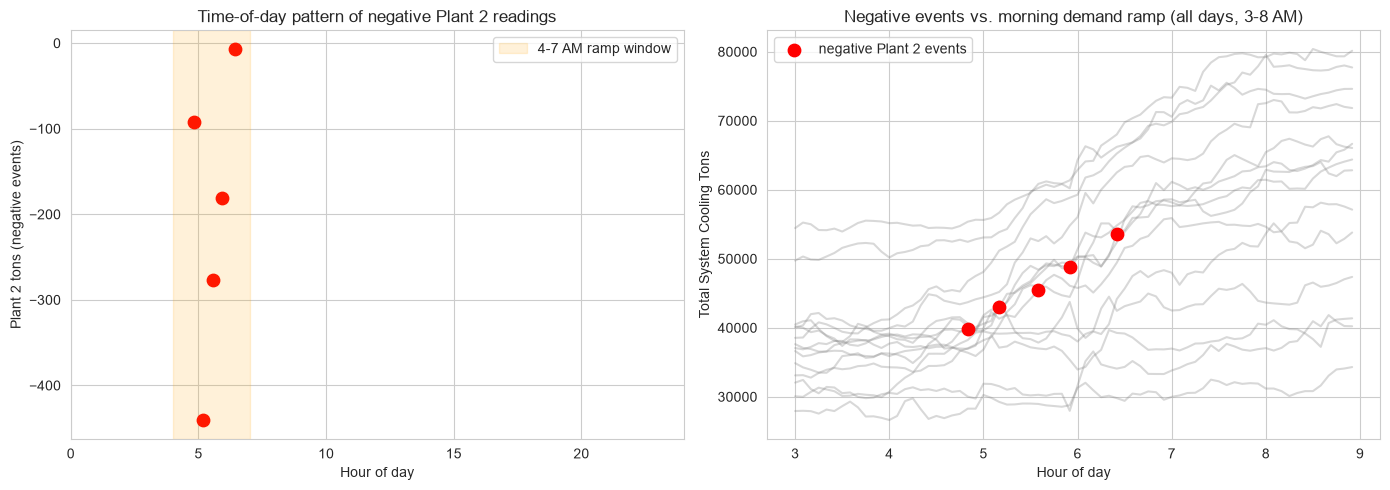

In [15]:
import matplotlib.pyplot as plt

# 1. Create a boolean mask directly instead of using a dataframe column
is_negative = df['plant_2_instantaneous_tons'] < 0

# 2. Filter down to negative events using the mask
neg_events = df[is_negative].copy()
neg_events['hour'] = neg_events['timestamp'].dt.hour + neg_events['timestamp'].dt.minute/60

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Where in the day do these fall?
axes[0].scatter(neg_events['hour'], neg_events['plant_2_instantaneous_tons'], color='red', s=80)
axes[0].set_xlim(0,24)
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Plant 2 tons (negative events)')
axes[0].set_title('Time-of-day pattern of negative Plant 2 readings')
axes[0].axvspan(4, 7, alpha=0.15, color='orange', label='4-7 AM ramp window')
axes[0].legend()

# Confirm it's tied to the plant 1 off -> total demand rising transition
window = df[(df['timestamp'].dt.hour>=3) & (df['timestamp'].dt.hour<=8)]
for day, grp in window.groupby(window['timestamp'].dt.date):
    axes[1].plot(grp['timestamp'].dt.hour + grp['timestamp'].dt.minute/60,
                 grp['total_system_cooling_tons'], alpha=0.3, color='gray')

# Map back to df using the same boolean mask index
axes[1].scatter(neg_events['hour'], 
                 df.loc[is_negative, 'total_system_cooling_tons'],
                 color='red', s=80, zorder=5, label='negative Plant 2 events')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Total System Cooling Tons')
axes[1].set_title('Negative events vs. morning demand ramp (all days, 3-8 AM)')
axes[1].legend()

plt.tight_layout()
plt.show()

All five negative tons for plant 2 were in a 2-hour early-morning window while Plant 1 is offline and demand is ramping, which could point to a metering artifact during a load transition rather than random sensor error. That's why I made the assumption to put them at 0 since corresponding column values are still valid

**Clean Plant 2 production readings based on operational clarification** 

In [16]:
# Preserve the original Plant 2 values for audit purposes
df["plant_2_tons_original"] = (
    df["plant_2_instantaneous_tons"].copy()
)

# Based on the operational clarification:
# 0 = plant not running
# 1 = erroneous reading, but generally means not running
# values greater than 1 = valid production in tons

df["plant_2_data_status"] = np.select(
    [
        df["plant_2_tons_original"] < 0,
        df["plant_2_tons_original"] <= 1,
        df["plant_2_tons_original"] > 1
    ],
    [
        "Invalid negative reading",
        "Off or erroneous reading",
        "Valid production"
    ],
    default="Missing"
)

# Treat all values <= 1 as zero production
df["plant_2_instantaneous_tons"] = np.where(
    df["plant_2_tons_original"] <= 1,
    0,
    df["plant_2_tons_original"]
)

# Create an operating-status field
df["plant_2_is_running"] = (
    df["plant_2_instantaneous_tons"] > 1
).astype(int)

print(df["plant_2_data_status"].value_counts())
print()
print(df["plant_2_is_running"].value_counts())

plant_2_data_status
Valid production            2918
Off or erroneous reading    1109
Invalid negative reading       5
Name: count, dtype: int64

plant_2_is_running
1    2918
0    1114
Name: count, dtype: int64


Values less than or equal to 1 are treated as zero production because 0 means
the plant is off and 1 is an erroneous reading that generally indicates the
plant is not running. Values greater than 1 represent valid production.

**Plant 1 Status**

In [17]:
df["plant_1_is_running"] = (
    df["plant_1_instantaneous_tons"] > 1
).astype(int)

In [18]:
print(df.shape)
df.tail()

(4032, 15)


,timestamp,customer_dp_psi,system_output_pressure_psi,system_return_temp_f,system_supply_temp_f,total_system_cooling_tons,total_system_flow_gpm,plant_1_instantaneous_tons,plant_2_instantaneous_tons,weather_timestamp,humidex_c,plant_2_tons_original,plant_2_data_status,plant_2_is_running,plant_1_is_running
4027,2026-07-14 23:35:00,15.919307,103.943118,52.058424,37.692760,51156.022023,72289.377003,0.0,2800.119691,NaT,NaN,2800.119691,Valid production,1,0
4028,2026-07-14 23:40:00,15.729461,104.099998,51.777817,37.695325,50173.178682,72454.687594,0.0,2069.349288,NaT,NaN,2069.349288,Valid production,1,0
4029,2026-07-14 23:45:00,15.581089,103.909160,51.804133,37.697889,48746.669408,72892.702722,0.0,1007.453997,NaT,NaN,1007.453997,Valid production,1,0
4030,2026-07-14 23:50:00,15.314144,103.699997,51.830449,37.700453,49357.898527,73373.704727,0.0,1421.392567,NaT,NaN,1421.392567,Valid production,1,0
4031,2026-07-14 23:55:00,15.207584,103.507354,52.021292,37.703017,49625.685822,74057.756620,0.0,1456.248744,NaT,NaN,1456.248744,Valid production,1,0


**Visualizing Plant 2 ton values for each day**

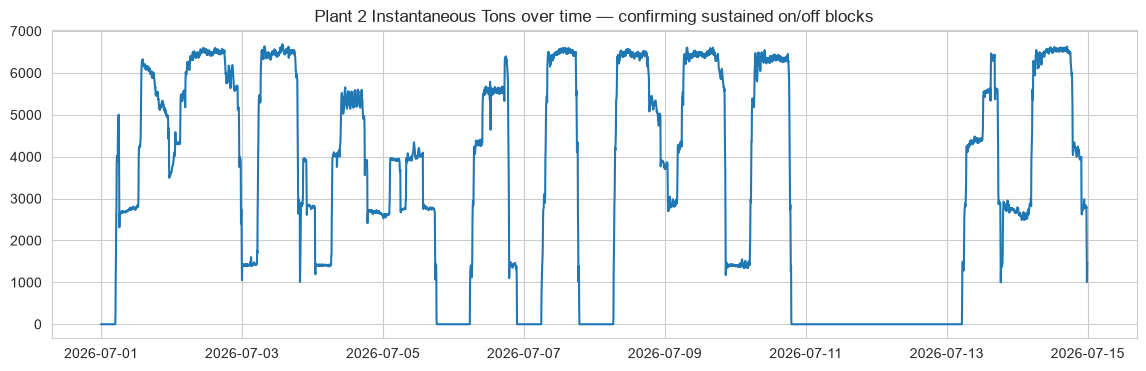

In [19]:
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(df['timestamp'], df['plant_2_instantaneous_tons'])
ax.set_title('Plant 2 Instantaneous Tons over time — confirming sustained on/off blocks')
plt.show()

**Checking what Plant 1 ton '-' values in excel could imply**

In [20]:
print(df['plant_1_instantaneous_tons'].apply(type).value_counts())   # should show only <class 'float'>
print((df['plant_1_instantaneous_tons'].astype(str) == '-').sum())    # should be 0 if it's a display format, not text

plant_1_instantaneous_tons
<class 'float'>    4032
Name: count, dtype: int64
0


**Confirming Plant_1_tons reading pattern**

In [21]:
# 1. Calculate plant activity mask
plant1_active = df['plant_1_instantaneous_tons'] > 0
print("Plant 1 active %:", plant1_active.mean().round(3))

# 2. Compute state changes and run-lengths purely in-memory
state_changes = plant1_active.ne(plant1_active.shift()).cumsum()
run_lengths = df.groupby(state_changes).size()

# 3. Output the run-length distribution metrics
print(run_lengths.describe())

Plant 1 active %: 0.25
count      17.000000
mean      237.176471
std       258.953962
min        54.000000
25%       125.000000
50%       150.000000
75%       172.000000
max      1030.000000
dtype: float64


- 17 runs total, minimum run length of 54 rows (4.5 hours), average run length ~237 rows (~20 hours), max run of 1,030 rows (~3.6 days)
- Random sensor dropout looks like scattered single points or short blips lasting seconds to a couple of minutes. What we have instead is Plant 1 staying off (or on) for hours-to-days at a stretch. This could imply a plant being staged in/out of service, not a data glitch.
- Plant 1 is active only 25% of the time, so this isn't noise around a baseline, it's possibly a genuine two-state operating mode (Plant 1 on vs. Plant 1 off) that spans most of your dataset.

**Visualizing Plant 1 ton values for each day**

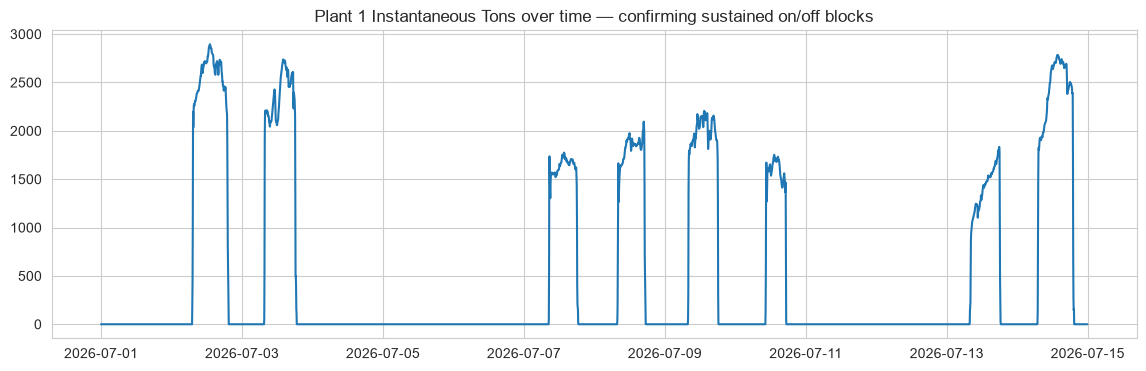

In [22]:

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(df['timestamp'], df['plant_1_instantaneous_tons'])
ax.set_title('Plant 1 Instantaneous Tons over time — confirming sustained on/off blocks')
plt.show()

**Outlier Visualization**

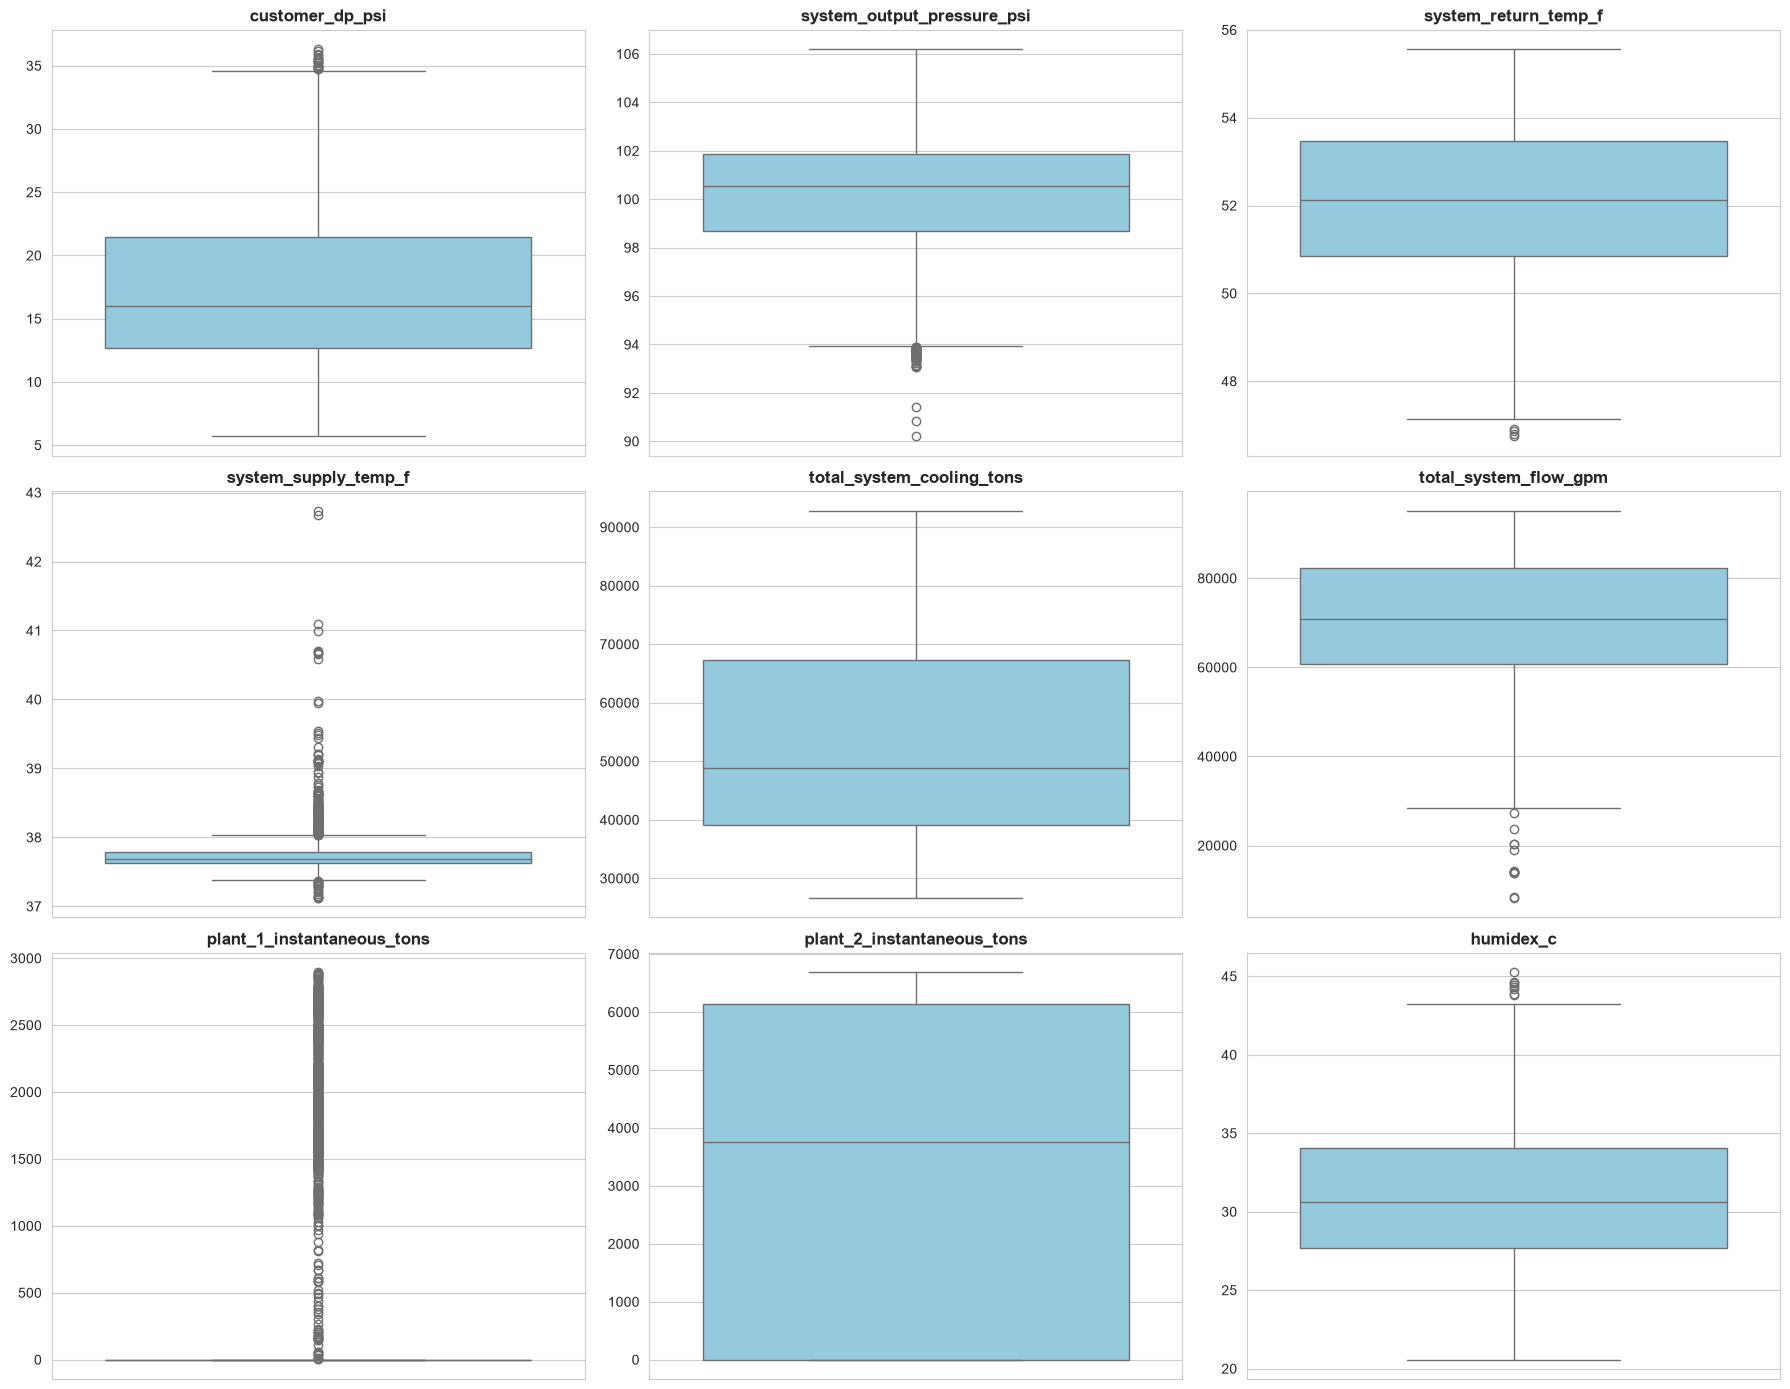

In [23]:

# 1. Define your 9 columns in a list
columns_to_plot = [
    'customer_dp_psi', 'system_output_pressure_psi', 'system_return_temp_f', 
    'system_supply_temp_f', 'total_system_cooling_tons', 'total_system_flow_gpm', 
    'plant_1_instantaneous_tons', 'plant_2_instantaneous_tons', 'humidex_c'
]

# 2. Set up a 3x3 grid for the 9 plots
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# 3. Flatten the 3x3 axes array to a 1D array of 9 elements for easy looping
axes = axes.flatten()

# 4. Loop through the columns and plot a box plot in each subplot slot
for i, col in enumerate(columns_to_plot):
    # Check if column exists in df to avoid unexpected KeyErrors
    if col in df.columns:
        sns.boxplot(data=df, y=col, ax=axes[i], color="skyblue")
        axes[i].set_title(col, fontsize=12, fontweight='bold')
        axes[i].set_ylabel('') # Clears y-label since the title handles it
    else:
        axes[i].text(0.5, 0.5, f"Column Not Found:\n{col}", 
                     ha='center', va='center', color='red')
        axes[i].axis('off')

# 5. Clean up layout spacing and display
plt.tight_layout()
plt.show()


- Tightly Controlled Metrics (Narrow Spreads): Columns like system_output_pressure_psi and system_supply_temp_f have very narrow boxes. This means they have low variability (a low standard deviation), showing that the system is highly stable and tightly regulated around its average.

- Highly Variable Metrics (Wide Spreads): Columns like total_system_cooling_tons, total_system_flow_gpm, and plant_2_instantaneous_tons have very tall boxes. This indicates a high range and high variance, meaning the plant's load changes drastically depending on demand.

- Heavy Outliers (Data Skewness): The dots outside the "whiskers" represent statistical outliers (unusual or extreme data points). For instance, system_supply_temp_f and plant_1_instantaneous_tons show long lines of dots extending upward, confirming a strong positive (right) skew where occasional spikes happen well above the normal operating range.

- Skewed Operational Ranges: The center horizontal line inside each box shows the median (the true middle value). In plant_2_instantaneous_tons, the box extends all the way down to 0, showing that while the plant frequently runs at high capacity, its lower half of data is heavily stretched, reflecting moments where it drops down to minimal operations.

- Plant 2 negative values will be set to 0 (only 5 rows, physically impossible as negative tonnage, and 0 is the natural floor rather than a fabricated number)
- Everything else was left untouched, treated as genuine operational variation
- No engineering-provided valid ranges were given for any sensor, so validity checks were based on physical plausibility (e.g., no negative tonnage/flow/pressure) rather than manufacturer or system specs — and outliers were treated as real operating conditions, not sensor error, in the absence of evidence otherwise.

In [24]:
print(df.shape)
df.tail()

(4032, 15)


,timestamp,customer_dp_psi,system_output_pressure_psi,system_return_temp_f,system_supply_temp_f,total_system_cooling_tons,total_system_flow_gpm,plant_1_instantaneous_tons,plant_2_instantaneous_tons,weather_timestamp,humidex_c,plant_2_tons_original,plant_2_data_status,plant_2_is_running,plant_1_is_running
4027,2026-07-14 23:35:00,15.919307,103.943118,52.058424,37.692760,51156.022023,72289.377003,0.0,2800.119691,NaT,NaN,2800.119691,Valid production,1,0
4028,2026-07-14 23:40:00,15.729461,104.099998,51.777817,37.695325,50173.178682,72454.687594,0.0,2069.349288,NaT,NaN,2069.349288,Valid production,1,0
4029,2026-07-14 23:45:00,15.581089,103.909160,51.804133,37.697889,48746.669408,72892.702722,0.0,1007.453997,NaT,NaN,1007.453997,Valid production,1,0
4030,2026-07-14 23:50:00,15.314144,103.699997,51.830449,37.700453,49357.898527,73373.704727,0.0,1421.392567,NaT,NaN,1421.392567,Valid production,1,0
4031,2026-07-14 23:55:00,15.207584,103.507354,52.021292,37.703017,49625.685822,74057.756620,0.0,1456.248744,NaT,NaN,1456.248744,Valid production,1,0


### ## 2. Exploratory Data Analysis (EDA)

**Distribution of Variables**

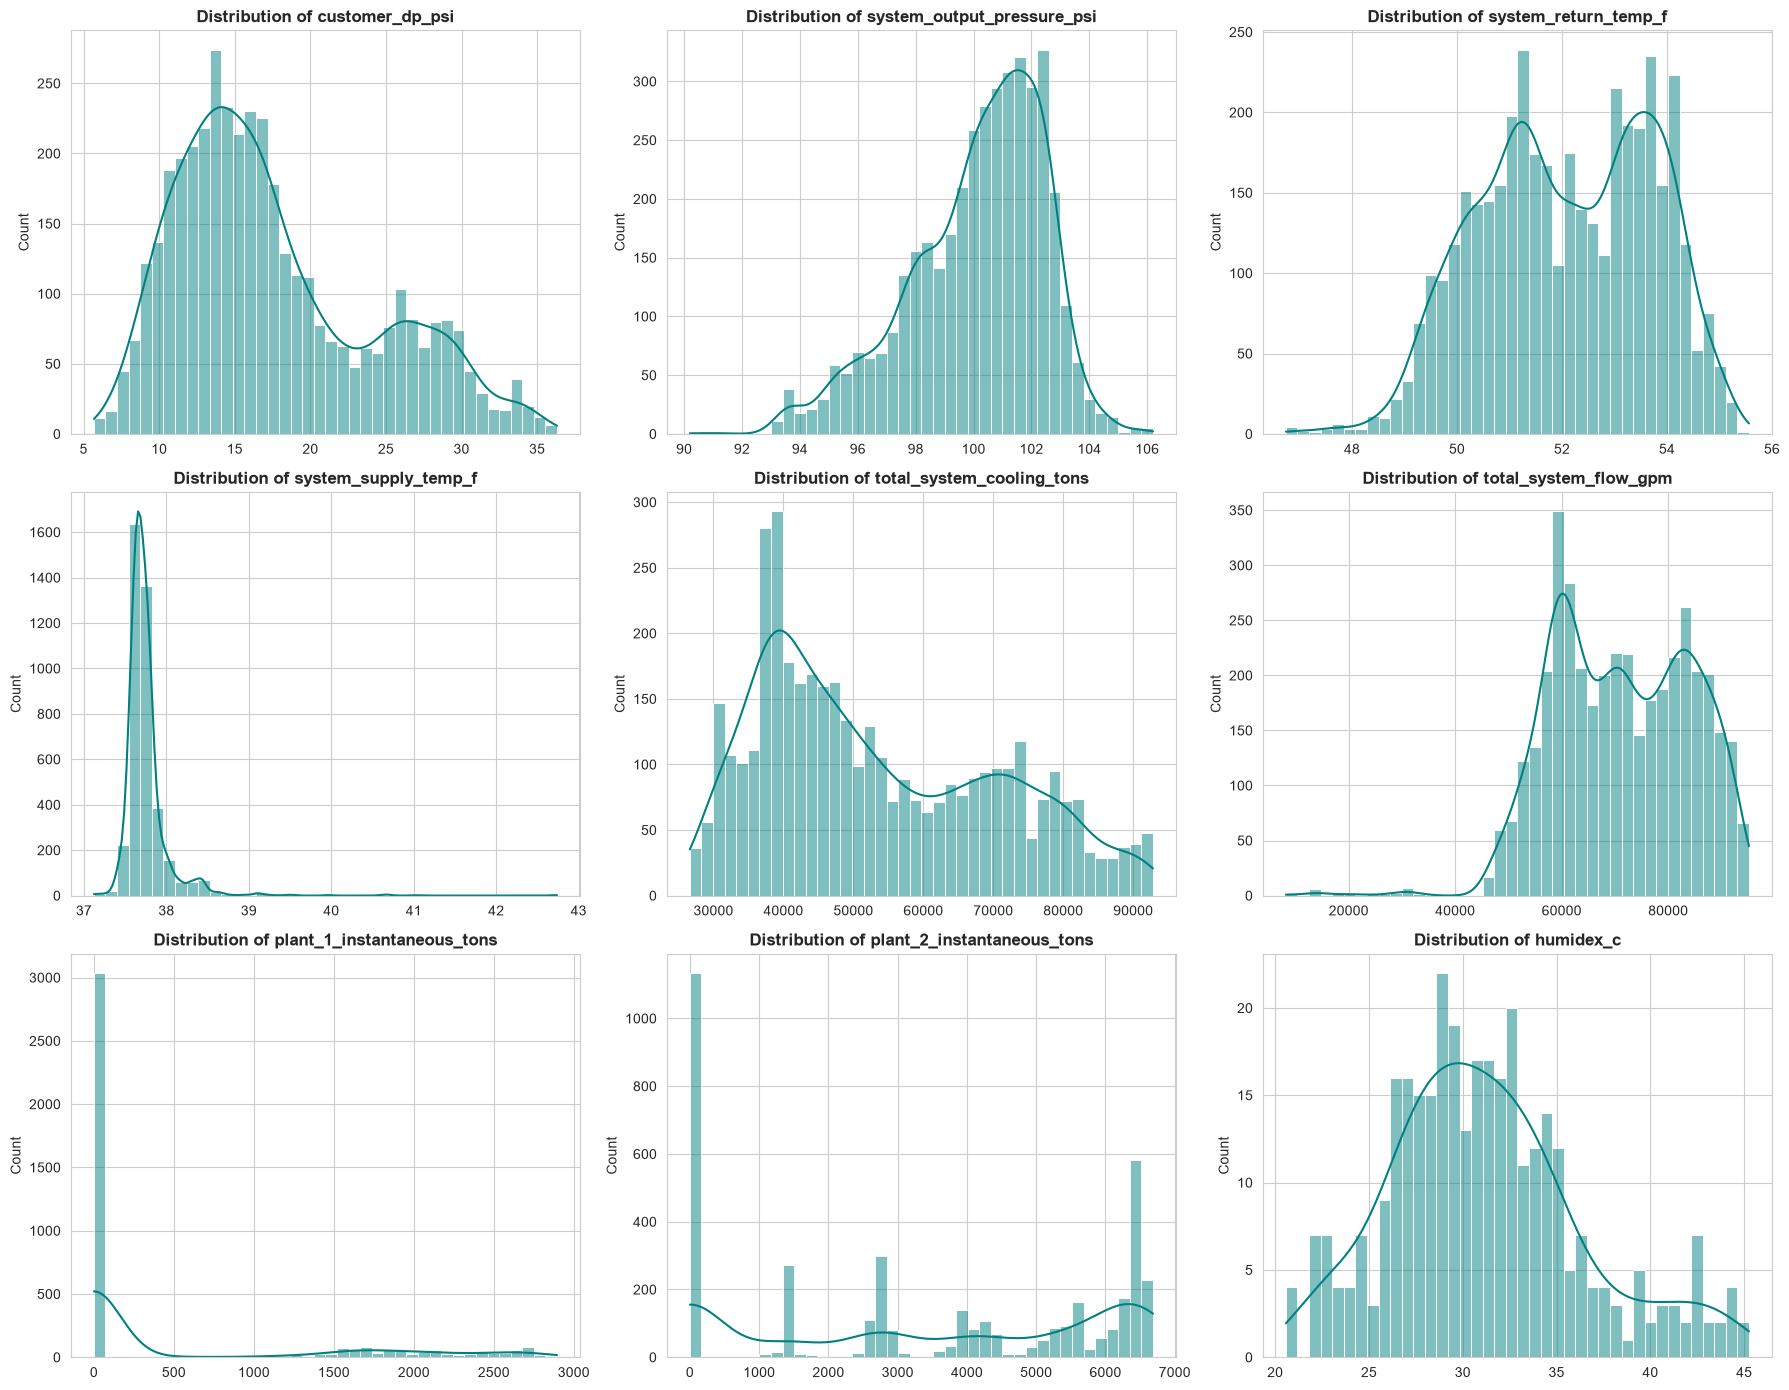

In [25]:

# 1. Define your 9 columns in a list
columns_to_plot = [
    'customer_dp_psi', 'system_output_pressure_psi', 'system_return_temp_f', 
    'system_supply_temp_f', 'total_system_cooling_tons', 'total_system_flow_gpm', 
    'plant_1_instantaneous_tons', 'plant_2_instantaneous_tons', 'humidex_c'
]

# 2. Set up a 3x3 grid for the 9 plots
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# 3. Flatten the 3x3 axes array to a 1D array of 9 elements for straightforward looping
axes = axes.flatten()

# 4. Loop through the columns and plot a histogram in each subplot slot
for i, col in enumerate(columns_to_plot):
    if col in df.columns:
        # kde=True adds a smooth density curve over the histogram bars
        sns.histplot(data=df, x=col, ax=axes[i], kde=True, color="teal", bins=40)
        axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')  # Clear x-label to keep the layout clean
        axes[i].set_ylabel('Count')
    else:
        axes[i].text(0.5, 0.5, f"Column Not Found:\n{col}", 
                     ha='center', va='center', color='red')
        axes[i].axis('off')

# 5. Clean up layout spacing and display
plt.tight_layout()
plt.show()

* **Operational Baselines:** System output pressure is tightly controlled around 100–102 PSI, while system supply temperature stays exceptionally stable near a crisp 37.5°F.
* **Bimodal Patterns:** Both system return temperature (peaks at 51°F and 54°F) and total flow rate show clear bimodal distributions, indicating two distinct plant operating states or load stages.
* **Plant Profiles:** Plant 1 serves primarily as a backup or staged unit (frequently sitting at 0 tons), whereas Plant 2 behaves as the primary workhorse, heavily loaded between 6,000–6,500 tons.
* **Ambient & System Load:** Total cooling tonnage spans a broad 30k–90k ton range, heavily mimicking the unimodal, right-skewed distribution of the local humidex data.

**Convert Weather Column as Celsius to Fahrenheit**

In [26]:
# Add Fahrenheit version of humidex for comparability with system temps
df['humidex_f'] = df['humidex_c'] * 9/5 + 32

df[['humidex_c','humidex_f','system_return_temp_f','system_supply_temp_f']].describe()

,humidex_c,humidex_f,system_return_temp_f,system_supply_temp_f
count,336.000000,336.000000,4032.000000,4032.000000
mean,31.187743,88.137937,52.080929,37.748392
std,5.165071,9.297127,1.618696,0.280108
min,20.572842,69.031115,46.741288,37.120437
25%,27.705851,81.870532,50.853571,37.623701
50%,30.625074,87.125133,52.114560,37.688968
75%,34.048370,93.287065,53.472124,37.790001
max,45.256144,113.461060,55.562248,42.737070


In [27]:
df.tail()

,timestamp,customer_dp_psi,system_output_pressure_psi,system_return_temp_f,system_supply_temp_f,total_system_cooling_tons,total_system_flow_gpm,plant_1_instantaneous_tons,plant_2_instantaneous_tons,weather_timestamp,humidex_c,plant_2_tons_original,plant_2_data_status,plant_2_is_running,plant_1_is_running,humidex_f
4027,2026-07-14 23:35:00,15.919307,103.943118,52.058424,37.692760,51156.022023,72289.377003,0.0,2800.119691,NaT,NaN,2800.119691,Valid production,1,0,NaN
4028,2026-07-14 23:40:00,15.729461,104.099998,51.777817,37.695325,50173.178682,72454.687594,0.0,2069.349288,NaT,NaN,2069.349288,Valid production,1,0,NaN
4029,2026-07-14 23:45:00,15.581089,103.909160,51.804133,37.697889,48746.669408,72892.702722,0.0,1007.453997,NaT,NaN,1007.453997,Valid production,1,0,NaN
4030,2026-07-14 23:50:00,15.314144,103.699997,51.830449,37.700453,49357.898527,73373.704727,0.0,1421.392567,NaT,NaN,1421.392567,Valid production,1,0,NaN
4031,2026-07-14 23:55:00,15.207584,103.507354,52.021292,37.703017,49625.685822,74057.756620,0.0,1456.248744,NaT,NaN,1456.248744,Valid production,1,0,NaN


**Operational and Weather Data Separation**

In [28]:
operational_columns = [
    "timestamp",
    "customer_dp_psi",
    "system_output_pressure_psi",
    "system_return_temp_f",
    "system_supply_temp_f",
    "total_system_cooling_tons",
    "total_system_flow_gpm",
    "plant_1_instantaneous_tons",
    "plant_2_instantaneous_tons",
    "plant_1_is_running",
    "plant_2_is_running",
    "plant_2_data_status"
]

weather_columns = [
    "weather_timestamp",
    "humidex_c", 
    'humidex_f'
]

# Ensure timestamps are datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["weather_timestamp"] = pd.to_datetime(
    df["weather_timestamp"],
    errors="coerce"
)

# Separate operational records
ops_df = (
    df[operational_columns]
    .dropna(subset=["timestamp"])
    .copy()
)

# Separate weather records
weather_df = (
    df[weather_columns]
    .dropna(subset=["weather_timestamp"])
    .copy()
)

print("Operational rows:", len(ops_df))
print("Weather rows:", len(weather_df))

Operational rows: 4032
Weather rows: 336


**merge: match by hour**

In [29]:
ops_df["hour_timestamp"] = ops_df["timestamp"].dt.floor("h")

weather_df["hour_timestamp"] = (
    weather_df["weather_timestamp"]
    .dt.floor("h")
)

# Remove duplicates in case more than one weather record exists per hour
weather_hourly = (
    weather_df[
        [
            "hour_timestamp",
            "humidex_c",
            "humidex_f"
        ]
    ]
    .drop_duplicates(subset=["hour_timestamp"])
)

# Merge hourly weather onto every 5-minute operational record
merged_df = ops_df.merge(
    weather_hourly,
    on="hour_timestamp",
    how="left",
    validate="many_to_one"
)

print(merged_df.shape)
print(merged_df.columns)
merged_df.head()

(4032, 15)
Index(['timestamp', 'customer_dp_psi', 'system_output_pressure_psi',
       'system_return_temp_f', 'system_supply_temp_f',
       'total_system_cooling_tons', 'total_system_flow_gpm',
       'plant_1_instantaneous_tons', 'plant_2_instantaneous_tons',
       'plant_1_is_running', 'plant_2_is_running', 'plant_2_data_status',
       'hour_timestamp', 'humidex_c', 'humidex_f'],
      dtype='str')


,timestamp,customer_dp_psi,system_output_pressure_psi,system_return_temp_f,system_supply_temp_f,total_system_cooling_tons,total_system_flow_gpm,plant_1_instantaneous_tons,plant_2_instantaneous_tons,plant_1_is_running,plant_2_is_running,plant_2_data_status,hour_timestamp,humidex_c,humidex_f
0,2026-07-01 00:00:00,14.170059,101.199997,51.234520,37.672530,41163.373867,68149.217188,0.0,0.0,0,0,Off or erroneous reading,2026-07-01,36.475639,97.656151
1,2026-07-01 00:05:00,14.077166,100.723169,51.228271,37.927261,43455.543771,68283.363807,0.0,0.0,0,0,Off or erroneous reading,2026-07-01,36.475639,97.656151
2,2026-07-01 00:10:00,14.695344,100.199997,51.158848,38.049999,44286.589818,67040.204584,0.0,0.0,0,0,Off or erroneous reading,2026-07-01,36.475639,97.656151
3,2026-07-01 00:15:00,14.658525,100.199997,50.411091,38.307150,43971.251370,67394.881378,0.0,0.0,0,0,Off or erroneous reading,2026-07-01,36.475639,97.656151
4,2026-07-01 00:20:00,14.459521,100.199997,50.085157,38.430000,43406.068006,67094.183255,0.0,0.0,0,0,Off or erroneous reading,2026-07-01,36.475639,97.656151


In [30]:
ops_df = ops_df.sort_values("timestamp")
weather_hourly = weather_df.sort_values("hour_timestamp")

In [31]:
print(
    merged_df[
        [
            "plant_2_instantaneous_tons",
            "plant_2_is_running",
            "plant_2_data_status"
        ]
    ].head()
)

   plant_2_instantaneous_tons  plant_2_is_running       plant_2_data_status
0                         0.0                   0  Off or erroneous reading
1                         0.0                   0  Off or erroneous reading
2                         0.0                   0  Off or erroneous reading
3                         0.0                   0  Off or erroneous reading
4                         0.0                   0  Off or erroneous reading


**Validate the merge**

In [32]:
print("Merged rows:", len(merged_df))

print(
    "Rows without weather:",
    merged_df["humidex_c"].isna().sum()
)

print(
    "Weather coverage:",
    merged_df["humidex_c"].notna().mean()
)

weather_duplicates = weather_df["hour_timestamp"].duplicated().sum()
print("Duplicate weather hours:", weather_duplicates)

Merged rows: 4032
Rows without weather: 0
Weather coverage: 1.0
Duplicate weather hours: 0


**Compare the time ranges**

In [33]:
print(
    "Operational range:",
    ops_df["timestamp"].min(),
    "to",
    ops_df["timestamp"].max()
)

print(
    "Weather range:",
    weather_df["weather_timestamp"].min(),
    "to",
    weather_df["weather_timestamp"].max()
)

Operational range: 2026-07-01 00:00:00 to 2026-07-14 23:55:00
Weather range: 2026-07-01 00:00:00 to 2026-07-14 23:00:00


In [34]:
merged_df.tail()

,timestamp,customer_dp_psi,system_output_pressure_psi,system_return_temp_f,system_supply_temp_f,total_system_cooling_tons,total_system_flow_gpm,plant_1_instantaneous_tons,plant_2_instantaneous_tons,plant_1_is_running,plant_2_is_running,plant_2_data_status,hour_timestamp,humidex_c,humidex_f
4027,2026-07-14 23:35:00,15.919307,103.943118,52.058424,37.692760,51156.022023,72289.377003,0.0,2800.119691,0,1,Valid production,2026-07-14 23:00:00,37.664142,99.795456
4028,2026-07-14 23:40:00,15.729461,104.099998,51.777817,37.695325,50173.178682,72454.687594,0.0,2069.349288,0,1,Valid production,2026-07-14 23:00:00,37.664142,99.795456
4029,2026-07-14 23:45:00,15.581089,103.909160,51.804133,37.697889,48746.669408,72892.702722,0.0,1007.453997,0,1,Valid production,2026-07-14 23:00:00,37.664142,99.795456
4030,2026-07-14 23:50:00,15.314144,103.699997,51.830449,37.700453,49357.898527,73373.704727,0.0,1421.392567,0,1,Valid production,2026-07-14 23:00:00,37.664142,99.795456
4031,2026-07-14 23:55:00,15.207584,103.507354,52.021292,37.703017,49625.685822,74057.756620,0.0,1456.248744,0,1,Valid production,2026-07-14 23:00:00,37.664142,99.795456


**Run data-quality check on Merged Dataframe (ops and weather)**

In [35]:
quality_summary = pd.DataFrame({
    "data_type": merged_df.dtypes.astype(str),
    "missing_count": merged_df.isna().sum(),
    "missing_pct": merged_df.isna().mean() * 100,
    "unique_values": merged_df.nunique(dropna=True),
    "minimum": merged_df.select_dtypes(
        include="number"
    ).min(),
    "maximum": merged_df.select_dtypes(
        include="number"
    ).max()
})

display(
    quality_summary.sort_values(
        "missing_pct",
        ascending=False
    )
)

,data_type,missing_count,missing_pct,unique_values,minimum,maximum
customer_dp_psi,float64,0,0.0,4032,5.684089,36.313799
hour_timestamp,datetime64[us],0,0.0,336,NaN,NaN
humidex_c,float64,0,0.0,326,20.572842,45.256144
humidex_f,float64,0,0.0,326,69.031115,113.461060
plant_1_instantaneous_tons,float64,0,0.0,1010,0.000000,2894.969882
plant_1_is_running,int64,0,0.0,2,0.000000,1.000000
plant_2_data_status,str,0,0.0,3,NaN,NaN
plant_2_instantaneous_tons,float64,0,0.0,2919,0.000000,6685.671045
plant_2_is_running,int64,0,0.0,2,0.000000,1.000000
system_output_pressure_psi,float64,0,0.0,2984,90.199997,106.199997


**Feature Engineering**

In [36]:
# ==============================
# Feature Engineering
# ==============================

merged_df["date"] = merged_df["timestamp"].dt.date
merged_df["hour"] = merged_df["timestamp"].dt.hour
merged_df["day_of_week"] = merged_df["timestamp"].dt.day_name()

merged_df["is_weekend"] = (
    merged_df["timestamp"].dt.dayofweek >= 5
).astype(int)

merged_df["temperature_delta_f"] = (
    merged_df["system_return_temp_f"]
    - merged_df["system_supply_temp_f"]
)

merged_df["pressure_gap_psi"] = (
    merged_df["system_output_pressure_psi"]
    - merged_df["customer_dp_psi"]
)

# ------------------------------
# NEW: Customer DP Threshold Features
# ------------------------------

DP_THRESHOLD = 12

merged_df["dp_margin_psi"] = (
    merged_df["customer_dp_psi"] - DP_THRESHOLD
)

merged_df["dp_upset"] = (
    merged_df["customer_dp_psi"] < DP_THRESHOLD
).astype(int)

merged_df["dp_status"] = np.where(
    merged_df["customer_dp_psi"] < DP_THRESHOLD,
    "Upset (<12 PSI)",
    "Normal (≥12 PSI)"
)



In [37]:
merged_df["dp_upset"].mean()

np.float64(0.21006944444444445)

- Customer DP was below the 12 psi upset threshold during approximately 21% of the recorded 5-minute for the recored period while 79% remained at or above the threshold. DP was below the threshold for approximately 21% of the monitored period

In [38]:
humidex_level = pd.qcut(merged_df['humidex_c'], 3, labels=['Low','Medium','High'])
merged_df['is_peak'] = (humidex_level == 'High').astype(int)

peak_exceedance = merged_df.loc[merged_df['is_peak']==1, 'dp_upset'].mean() * 100
print(f"Peak conditions -- % of 5-min intervals below 12 psi: {peak_exceedance:.1f}%")

nonpeak = merged_df[merged_df['is_peak']==0].set_index('timestamp')
hourly_avg = nonpeak.resample('1h')['customer_dp_psi'].mean()
nonpeak_exceedance = (hourly_avg < 12).mean() * 100
print(f"Non-peak conditions -- % of HOURLY averages below 12 psi: {nonpeak_exceedance:.1f}%")

Peak conditions -- % of 5-min intervals below 12 psi: 36.6%
Non-peak conditions -- % of HOURLY averages below 12 psi: 9.1%


**Validating Columns**

In [39]:
print(
    merged_df[
        [
            "customer_dp_psi",
            "dp_margin_psi",
            "dp_upset",
            "dp_status"
        ]
    ].head(10)
)

print("\nDP status counts:")
print(merged_df["dp_status"].value_counts())

print(
    f"\nOverall upset rate: "
    f"{merged_df['dp_upset'].mean() * 100:.2f}%"
)

print(
    f"Minimum customer DP: "
    f"{merged_df['customer_dp_psi'].min():.2f} PSI"
)

   customer_dp_psi  dp_margin_psi  dp_upset         dp_status
0        14.170059       2.170059         0  Normal (≥12 PSI)
1        14.077166       2.077166         0  Normal (≥12 PSI)
2        14.695344       2.695344         0  Normal (≥12 PSI)
3        14.658525       2.658525         0  Normal (≥12 PSI)
4        14.459521       2.459521         0  Normal (≥12 PSI)
5        13.500212       1.500212         0  Normal (≥12 PSI)
6        12.187216       0.187216         0  Normal (≥12 PSI)
7        13.098895       1.098895         0  Normal (≥12 PSI)
8        13.479225       1.479225         0  Normal (≥12 PSI)
9        12.896493       0.896493         0  Normal (≥12 PSI)

DP status counts:
dp_status
Normal (≥12 PSI)    3185
Upset (<12 PSI)      847
Name: count, dtype: int64

Overall upset rate: 21.01%
Minimum customer DP: 5.68 PSI


**threshold Customer DP performance**

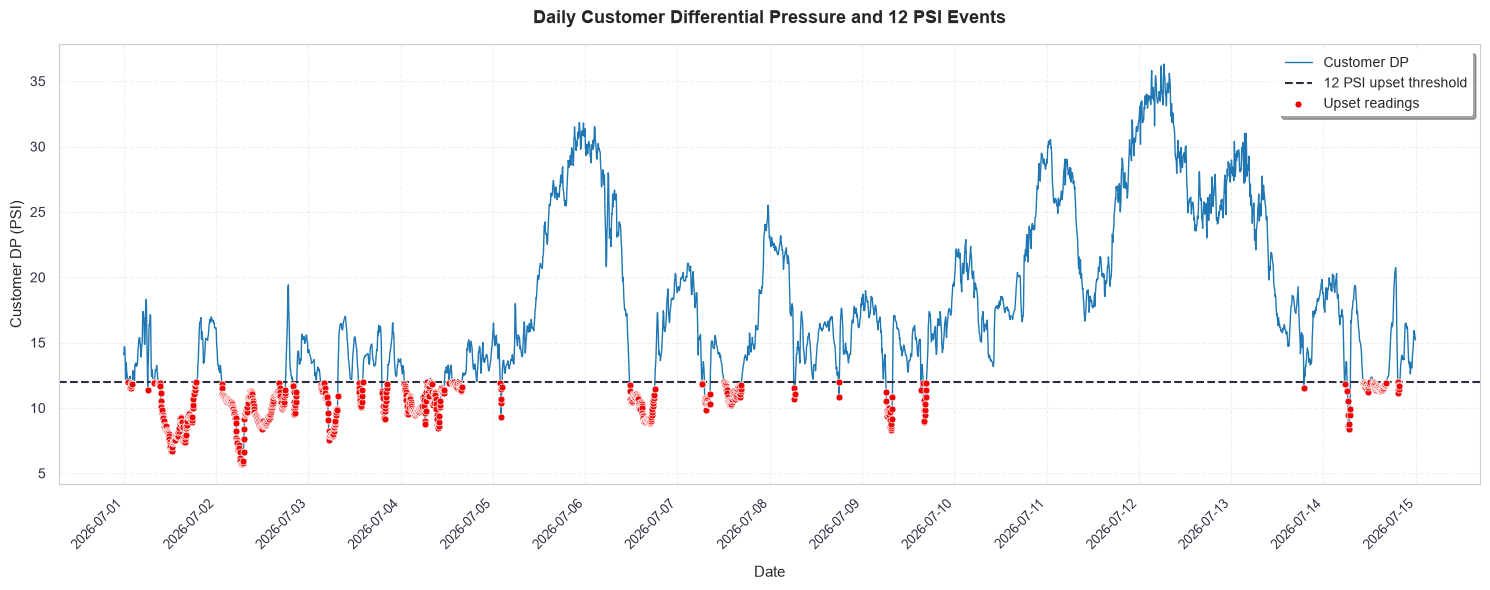

In [40]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(15, 6)) # Tall height gives slanted labels room to breathe

# 1. Main time-series line
plt.plot(
    merged_df["timestamp"],
    merged_df["customer_dp_psi"],
    color="#1f77b4",
    linewidth=1,
    label="Customer DP",
    zorder=1
)

# 2. Reference Limit Line
plt.axhline(
    y=DP_THRESHOLD,
    color="#2b2d42",
    linestyle="--",
    linewidth=1.5,
    label="12 PSI upset threshold",
    zorder=2
)

# 3. Highlighted Upset Points
plt.scatter(
    merged_df.loc[merged_df["dp_upset"] == 1, "timestamp"],
    merged_df.loc[merged_df["dp_upset"] == 1, "customer_dp_psi"],
    color="#ee0404",
    s=25,                  
    edgecolor="white",     
    linewidth=0.5,
    label="Upset readings",
    zorder=3               
)

# --- Enhanced Axis & Tick Controls ---
ax = plt.gca()

# Force a tick/label onto every single unique calendar day in the dataset
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1)) 

# Format the dates visually as YYYY-MM-DD
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# Slant the labels at 45 degrees and anchor by the right edge for clean alignment
plt.xticks(rotation=45, ha='right', fontsize=9)

# Explicitly display dark, crisp tick marks on both axes pointing outwards
ax.tick_params(axis='both', which='both', direction='out', length=6, width=1, colors='#2b2d42')

# Styling, Labels, and Layout
plt.title("Daily Customer Differential Pressure and 12 PSI Events", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=11, labelpad=10)
plt.ylabel("Customer DP (PSI)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.3)

plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", shadow=True)

# Automatically handles margins so the rotated date strings aren't clipped
plt.tight_layout()
plt.show()

**Operational threshold summary**

In [41]:
# ==============================
# Customer DP Threshold Summary
# ==============================

DP_THRESHOLD = 12
INTERVAL_MINUTES = 5

total_readings = len(merged_df)

upset_readings = merged_df["dp_upset"].sum()

normal_readings = total_readings - upset_readings

upset_rate = merged_df["dp_upset"].mean() * 100

normal_rate = 100 - upset_rate

dp_summary = pd.DataFrame({
    "Metric": [
        "Total 5-minute readings",
        "Average customer DP",
        "Median customer DP",
        "Minimum customer DP",
        "Maximum customer DP",
        "Readings below 12 PSI",
        "Readings at or above 12 PSI",
        "Percentage below 12 PSI",
        "Percentage at or above 12 PSI",
        "Average DP margin",
        "Worst DP margin"
    ],
    "Value": [
        total_readings,
        merged_df["customer_dp_psi"].mean(),
        merged_df["customer_dp_psi"].median(),
        merged_df["customer_dp_psi"].min(),
        merged_df["customer_dp_psi"].max(),
        upset_readings,
        normal_readings,
        upset_rate,
        normal_rate,
        merged_df["dp_margin_psi"].mean(),
        merged_df["dp_margin_psi"].min()
    ],
    "Unit": [
        "readings",
        "PSI",
        "PSI",
        "PSI",
        "PSI",
        "readings",
        "readings",
        "%",
        "%",
        "PSI",
        "PSI"
    ]
})

dp_summary["Value"] = dp_summary["Value"].round(2)

dp_summary

,Metric,Value,Unit
0,Total 5-minute readings,4032.00,readings
1,Average customer DP,17.51,PSI
2,Median customer DP,15.99,PSI
3,Minimum customer DP,5.68,PSI
4,Maximum customer DP,36.31,PSI
5,Readings below 12 PSI,847.00,readings
6,Readings at or above 12 PSI,3185.00,readings
7,Percentage below 12 PSI,21.01,%
8,Percentage at or above 12 PSI,78.99,%
9,Average DP margin,5.51,PSI


**Identify separate upset events**

In [42]:
# ==============================
# Identify Consecutive DP Upset Events
# ==============================

merged_df = (
    merged_df
    .sort_values("timestamp")
    .reset_index(drop=True)
    .copy()
)

# Identify when DP status changes from normal to upset or upset to normal
merged_df["dp_status_change"] = (
    merged_df["dp_upset"] !=
    merged_df["dp_upset"].shift()
)

# Give each continuous block a unique identifier
merged_df["dp_status_group"] = (
    merged_df["dp_status_change"].cumsum()
)

# Keep only continuous periods where DP was below 12 PSI
upset_events = (
    merged_df[
        merged_df["dp_upset"] == 1
    ]
    .groupby("dp_status_group")
    .agg(
        event_start=("timestamp", "min"),
        event_end=("timestamp", "max"),
        number_of_readings=("timestamp", "size"),
        average_dp_psi=("customer_dp_psi", "mean"),
        minimum_dp_psi=("customer_dp_psi", "min"),
        average_flow_gpm=("total_system_flow_gpm", "mean"),
        maximum_flow_gpm=("total_system_flow_gpm", "max"),
        average_cooling_tons=("total_system_cooling_tons", "mean"),
        average_output_pressure_psi=(
            "system_output_pressure_psi",
            "mean"
        ),
        average_humidex_c=("humidex_c", "mean")
    )
    .reset_index(drop=True)
)

# Each observation represents approximately 5 minutes
upset_events["duration_minutes"] = (
    upset_events["number_of_readings"] * 5
    
)

upset_events["average_dp_psi"] = (
    upset_events["average_dp_psi"].round(2)
)

upset_events["minimum_dp_psi"] = (
    upset_events["minimum_dp_psi"].round(2)
)

upset_events["average_flow_gpm"] = (
    upset_events["average_flow_gpm"].round(2)
)

upset_events["maximum_flow_gpm"] = (
    upset_events["maximum_flow_gpm"].round(2)
)

upset_events["average_cooling_tons"] = (
    upset_events["average_cooling_tons"].round(2)
)

upset_events["average_output_pressure_psi"] = (
    upset_events["average_output_pressure_psi"].round(2)
)

upset_events["average_humidex_c"] = (
    upset_events["average_humidex_c"].round(2)
)

upset_events["elapsed_minutes"] = (
    upset_events["event_end"] -
    upset_events["event_start"]
).dt.total_seconds() / 60


upset_events.head()

,event_start,event_end,number_of_readings,average_dp_psi,minimum_dp_psi,average_flow_gpm,maximum_flow_gpm,average_cooling_tons,average_output_pressure_psi,average_humidex_c,duration_minutes,elapsed_minutes
0,2026-07-01 01:15:00,2026-07-01 01:15:00,1,11.99,11.99,67878.93,67878.93,41415.45,95.26,36.49,5,0.0
1,2026-07-01 01:45:00,2026-07-01 02:05:00,5,11.70,11.50,65512.81,65946.15,42070.75,93.63,36.49,25,20.0
2,2026-07-01 02:15:00,2026-07-01 02:15:00,1,11.87,11.87,64911.07,64911.07,41757.74,93.70,36.48,5,0.0
3,2026-07-01 06:15:00,2026-07-01 06:15:00,1,11.35,11.35,61920.39,61920.39,39084.53,90.83,33.42,5,0.0
4,2026-07-01 07:55:00,2026-07-01 08:00:00,2,11.94,11.88,76925.85,76954.14,52711.71,102.68,36.78,10,5.0


**event-level metrics**

In [43]:
# ==============================
# Add Upset Event Metrics
# ==============================

event_summary = pd.DataFrame({
    "Metric": [
        "Number of separate upset events",
        "Average upset duration",
        "Median upset duration",
        "Longest upset duration",
        "Shortest upset duration",
        "Lowest recorded DP during an upset"
    ],
    "Value": [
        len(upset_events),
        upset_events["duration_minutes"].mean(),
        upset_events["duration_minutes"].median(),
        upset_events["duration_minutes"].max(),
        upset_events["duration_minutes"].min(),
        upset_events["minimum_dp_psi"].min()
    ],
    "Unit": [
        "events",
        "minutes",
        "minutes",
        "minutes",
        "minutes",
        "PSI"
    ]
})

event_summary["Value"] = event_summary["Value"].round(2)

event_summary

,Metric,Value,Unit
0,Number of separate upset events,37.00,events
1,Average upset duration,114.46,minutes
2,Median upset duration,35.00,minutes
3,Longest upset duration,995.00,minutes
4,Shortest upset duration,5.00,minutes
5,Lowest recorded DP during an upset,5.68,PSI


**KPI Table**

In [44]:
complete_dp_summary = pd.concat(
    [
        dp_summary,
        event_summary
    ],
    ignore_index=True
)

complete_dp_summary

,Metric,Value,Unit
0,Total 5-minute readings,4032.00,readings
1,Average customer DP,17.51,PSI
2,Median customer DP,15.99,PSI
3,Minimum customer DP,5.68,PSI
4,Maximum customer DP,36.31,PSI
5,Readings below 12 PSI,847.00,readings
6,Readings at or above 12 PSI,3185.00,readings
7,Percentage below 12 PSI,21.01,%
8,Percentage at or above 12 PSI,78.99,%
9,Average DP margin,5.51,PSI


**most severe upset events**

In [45]:
most_severe_events = (
    upset_events
    .sort_values(
        by=[
            "minimum_dp_psi",
            "duration_minutes"
        ],
        ascending=[
            True,
            False
        ]
    )
    .head(10)
)

most_severe_events[
    [
        "event_start",
        "event_end",
        "duration_minutes",
        "minimum_dp_psi",
        "average_dp_psi",
        "average_flow_gpm",
        "average_cooling_tons",
        "average_output_pressure_psi",
        "average_humidex_c"
    ]
]

,event_start,event_end,duration_minutes,minimum_dp_psi,average_dp_psi,average_flow_gpm,average_cooling_tons,average_output_pressure_psi,average_humidex_c
7,2026-07-02 01:30:00,2026-07-02 18:00:00,995,5.68,9.64,88848.86,76617.33,95.85,37.85
6,2026-07-01 09:20:00,2026-07-01 18:50:00,575,6.68,8.78,82120.49,62272.92,98.68,42.26
9,2026-07-03 03:15:00,2026-07-03 07:40:00,270,7.56,9.75,83590.73,59821.21,96.72,33.07
26,2026-07-09 06:15:00,2026-07-09 07:55:00,105,8.31,9.54,84454.46,65500.57,100.56,30.84
31,2026-07-14 06:15:00,2026-07-14 06:55:00,45,8.40,9.44,89838.84,67079.01,101.36,31.92
13,2026-07-04 07:50:00,2026-07-04 11:20:00,215,8.43,10.56,69208.89,50186.70,99.94,32.75
12,2026-07-04 01:00:00,2026-07-04 07:35:00,400,8.81,10.32,60776.34,39476.70,96.81,31.63
19,2026-07-06 11:35:00,2026-07-06 18:05:00,395,8.88,10.05,87846.14,70874.71,101.28,30.47
28,2026-07-09 15:55:00,2026-07-09 16:45:00,55,8.92,10.37,86506.43,80776.94,99.87,31.33
11,2026-07-03 19:10:00,2026-07-03 20:30:00,85,9.15,10.40,78300.81,56510.14,103.36,36.62


**longest events**

In [46]:
longest_upset_events = (
    upset_events
    .sort_values(
        "duration_minutes",
        ascending=False
    )
    .head(10)
)

longest_upset_events[
    [
        "event_start",
        "event_end",
        "duration_minutes",
        "minimum_dp_psi",
        "average_dp_psi",
        "average_flow_gpm",
        "average_cooling_tons",
        "average_humidex_c"
    ]
]

,event_start,event_end,duration_minutes,minimum_dp_psi,average_dp_psi,average_flow_gpm,average_cooling_tons,average_humidex_c
7,2026-07-02 01:30:00,2026-07-02 18:00:00,995,5.68,9.64,88848.86,76617.33,37.85
6,2026-07-01 09:20:00,2026-07-01 18:50:00,575,6.68,8.78,82120.49,62272.92,42.26
12,2026-07-04 01:00:00,2026-07-04 07:35:00,400,8.81,10.32,60776.34,39476.70,31.63
19,2026-07-06 11:35:00,2026-07-06 18:05:00,395,8.88,10.05,87846.14,70874.71,30.47
9,2026-07-03 03:15:00,2026-07-03 07:40:00,270,7.56,9.75,83590.73,59821.21,33.07
23,2026-07-07 12:20:00,2026-07-07 16:35:00,260,10.20,11.04,90534.18,73468.13,31.83
13,2026-07-04 07:50:00,2026-07-04 11:20:00,215,8.43,10.56,69208.89,50186.70,32.75
35,2026-07-14 12:55:00,2026-07-14 16:15:00,205,11.33,11.59,91634.83,89815.94,44.05
26,2026-07-09 06:15:00,2026-07-09 07:55:00,105,8.31,9.54,84454.46,65500.57,30.84
21,2026-07-07 07:05:00,2026-07-07 08:30:00,90,9.85,10.46,85903.54,63742.15,28.30


### 3. Driver Analysis - Exploring Drivers of Customer DP**

**Correlation Analysis*

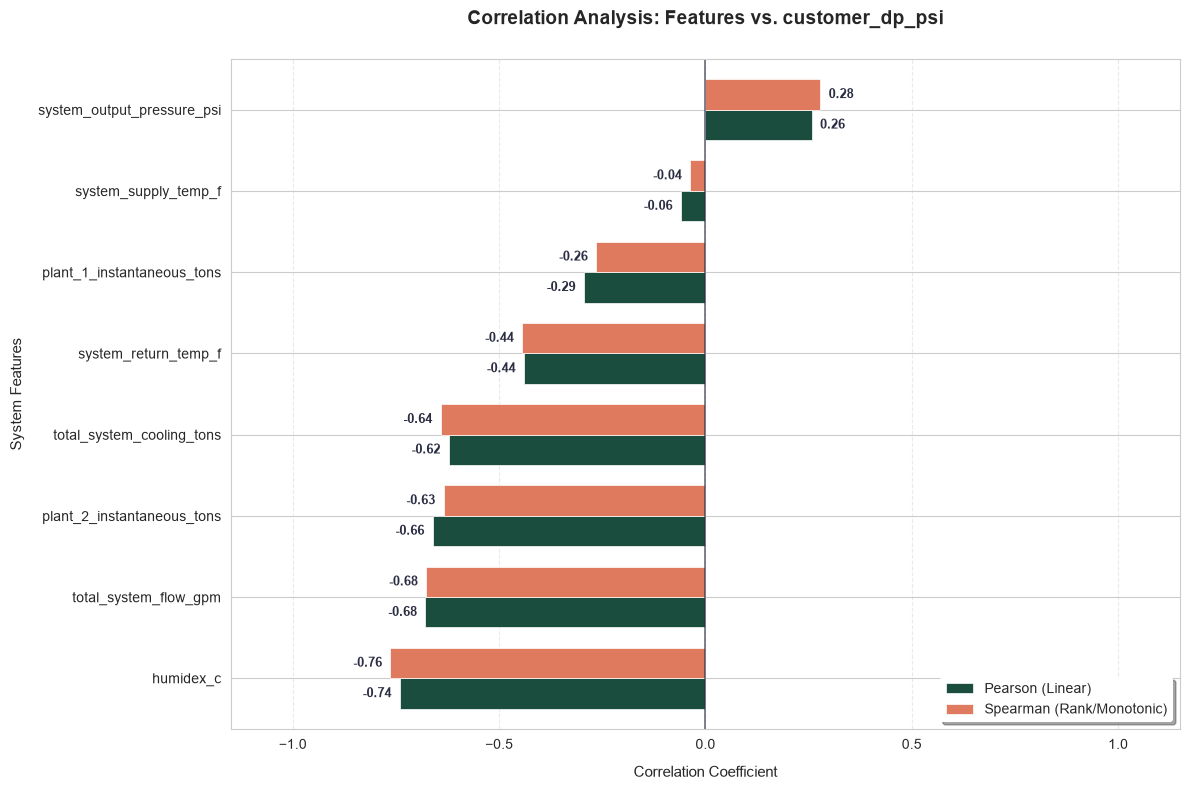

In [47]:
num_cols = [
    'customer_dp_psi', 'system_output_pressure_psi', 'system_return_temp_f',
    'system_supply_temp_f', 'total_system_cooling_tons', 'total_system_flow_gpm',
    'plant_1_instantaneous_tons', 'plant_2_instantaneous_tons', 'humidex_c'
]

# 1. Compute the full correlation matrices first
pearson_matrix = merged_df[num_cols].corr(method='pearson')
spearman_matrix = merged_df[num_cols].corr(method='spearman')

# 2. Extract the specific series for customer_dp_psi
pearson_series = pearson_matrix['customer_dp_psi']
spearman_series = spearman_matrix['customer_dp_psi']

# 3. Combine into the plotting DataFrame and drop the self-correlation
corr_df = pd.DataFrame({
    'Pearson (Linear)': pearson_series,
    'Spearman (Rank/Monotonic)': spearman_series
}).drop(index='customer_dp_psi')

corr_df = corr_df.sort_values(by='Pearson (Linear)')

# --- Plotting Code ---
fig, ax = plt.subplots(figsize=(12, 8))

corr_df.plot(
    kind='barh', 
    ax=ax, 
    color=['#1b4d3e', '#e07a5f'], 
    width=0.75,
    edgecolor='white',
    linewidth=0.5
)

for container in ax.containers:
    labels = [f'{v:.2f}' if v != 0 else '' for v in container.datavalues]
    ax.bar_label(
        container, 
        labels=labels,
        padding=6,      
        fontsize=9, 
        fontweight='bold',
        color='#2b2d42'
    )

ax.set_title('Correlation Analysis: Features vs. customer_dp_psi', fontsize=14, fontweight='bold', pad=25)
ax.set_xlabel('Correlation Coefficient', fontsize=11, labelpad=10)
ax.set_ylabel('System Features', fontsize=11, labelpad=10)
ax.set_xlim(-1.15, 1.15) 
ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.axvline(0, color='#2b2d42', linestyle='-', linewidth=1.2, alpha=0.7)
ax.legend(frameon=True, facecolor='white', edgecolor='none', shadow=True, loc='lower right')

plt.tight_layout()
plt.show()

- I sorted and color-coded by direction so a stakeholder can read the story in five seconds, without needing to interpret a matrix." Note: humidex_c and humidex_f will show the same correlation value (one's just a unit conversion of the other). I kept both temporarily for the join, I'll drop one before regression to avoid double-counting the same signal.

In [48]:
status_cols = ['customer_dp_psi', 'plant_1_is_running', 'plant_2_is_running']
merged_df[status_cols].corr()['customer_dp_psi']

customer_dp_psi       1.000000
plant_1_is_running   -0.265974
plant_2_is_running   -0.710206
Name: customer_dp_psi, dtype: float64

**Feature Correlation**

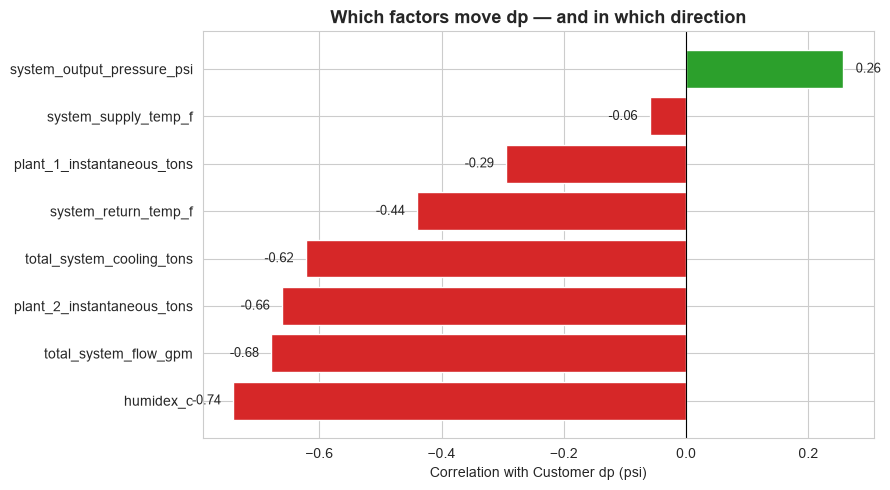

In [49]:
target_corr = merged_df[num_cols].drop(columns='customer_dp_psi').corrwith(merged_df['customer_dp_psi'])
target_corr = target_corr.sort_values()

plt.figure(figsize=(9,5))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with Customer dp (psi)')
plt.title('Which factors move dp — and in which direction', fontsize=13, fontweight='bold')
for i, v in enumerate(target_corr.values):
    plt.text(v + (0.02 if v>=0 else -0.02), i, f'{v:.2f}', va='center',
              ha='left' if v>=0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('driver_ranking.png', dpi=150)
plt.show()

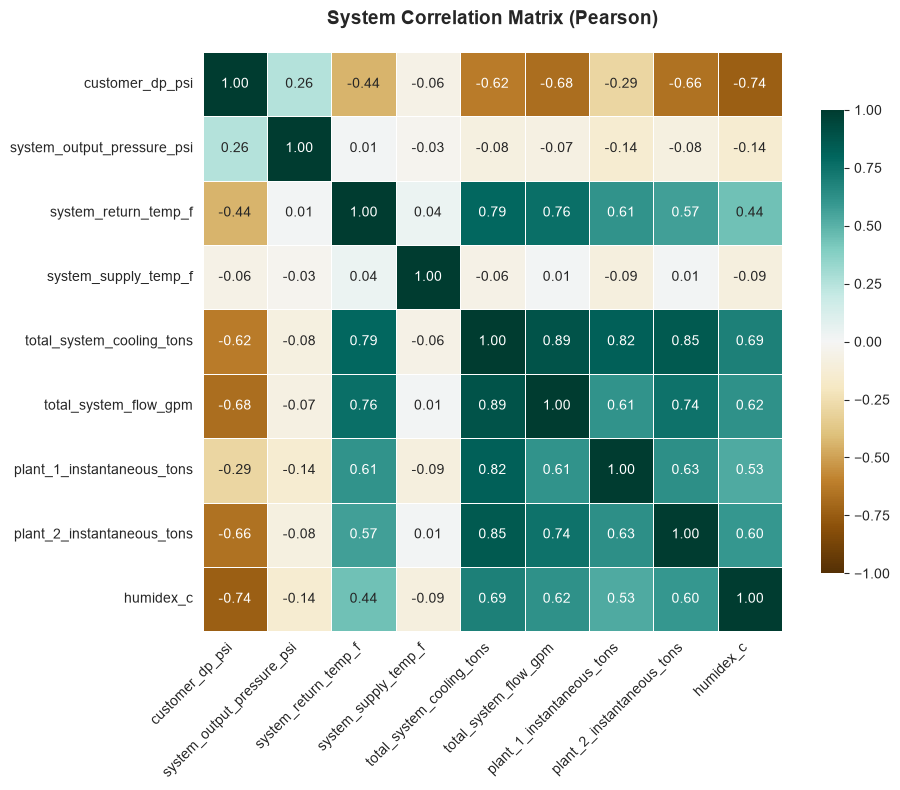

In [50]:
# 1. Define the numerical columns explicitly
num_cols = [
    'customer_dp_psi', 'system_output_pressure_psi', 'system_return_temp_f',
    'system_supply_temp_f', 'total_system_cooling_tons', 'total_system_flow_gpm',
    'plant_1_instantaneous_tons', 'plant_2_instantaneous_tons', 'humidex_c'
]

# 2. Compute the matrix inside the cell to clear VS Code linter warnings
pearson_corr = merged_df[num_cols].corr(method='pearson')

# 3. Assign it to your target matrix variable
target_matrix = pearson_corr 

# --- Plotting Code ---
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    target_matrix,
    annot=True,              
    fmt=".2f",               
    cmap="BrBG",             
    vmin=-1, vmax=1,         
    center=0,
    square=True,             
    linewidths=0.5,          
    cbar_kws={"shrink": 0.8} 
)

ax.set_title('System Correlation Matrix (Pearson)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Scatter + trend line for the top 3 drivers**

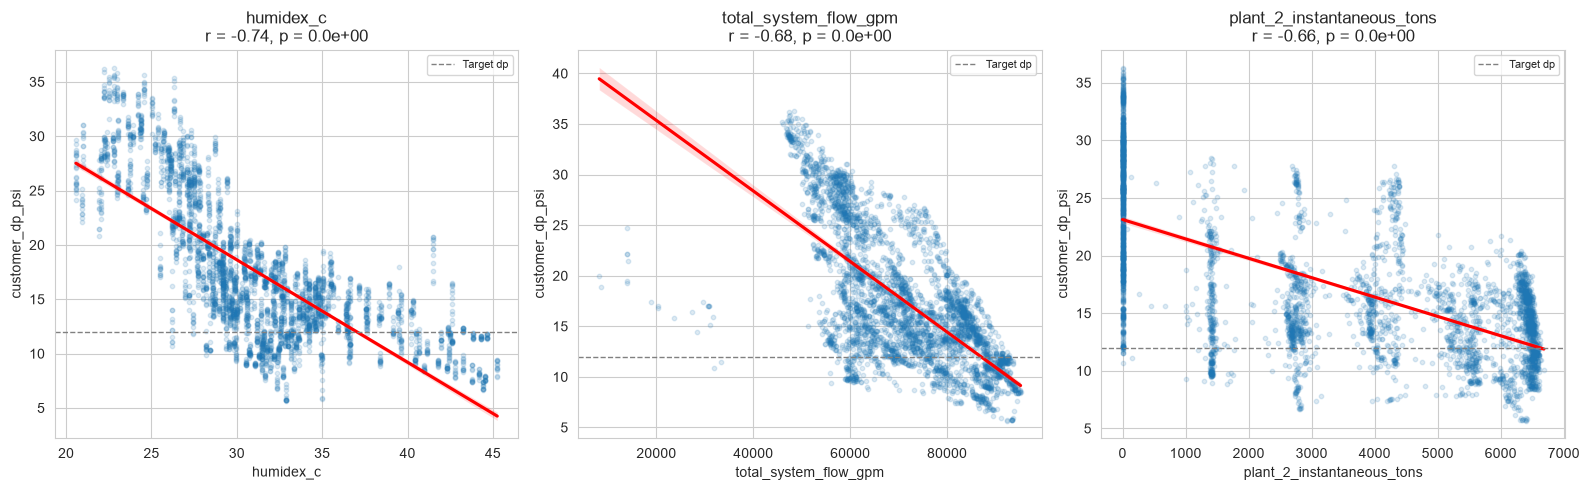

In [51]:
from scipy import stats
top_drivers = target_corr.abs().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, col in zip(axes, top_drivers):
    sns.regplot(data=merged_df, x=col, y='customer_dp_psi', ax=ax,
                scatter_kws={'alpha':0.15, 's':10}, line_kws={'color':'red'})
    r, p = stats.pearsonr(merged_df[col], merged_df['customer_dp_psi'])
    ax.set_title(f'{col}\nr = {r:.2f}, p = {p:.1e}')
    ax.axhline(12, color='gray', linestyle='--', linewidth=1, label='Target dp')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('top_drivers_scatter.png', dpi=150)
plt.show()

**Check for curvature (non-linearity) on the strongest driver**

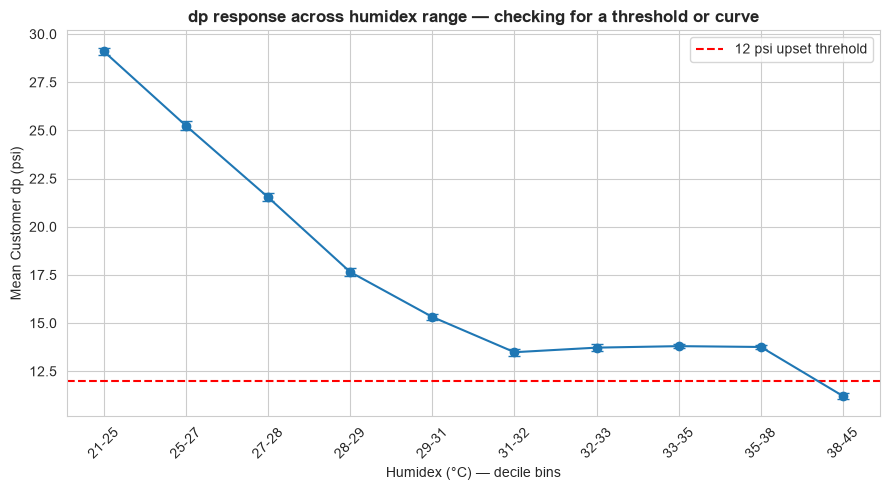

In [84]:
# 1. Create the binning sequence strictly in memory
humidex_bins = pd.qcut(merged_df['humidex_c'], 10)

# 2. Group the target column by passing the standalone Series
binned = merged_df.groupby(humidex_bins, observed=True)['customer_dp_psi'].agg(['mean', 'std', 'count'])

# --- Plotting Code ---
plt.figure(figsize=(9, 5))

# Plot the standard error of the mean (SEM)
plt.errorbar(
    range(len(binned)), 
    binned['mean'], 
    yerr=binned['std'] / binned['count']**0.5,
    marker='o', 
    capsize=4, 
    color='#1f77b4'
)

plt.axhline(12, color='red', linestyle='--', label='12 psi upset threhold')

# Format the x-axis labels to show the bin edges clearly
plt.xticks(
    range(len(binned)), 
    [f'{i.left:.0f}-{i.right:.0f}' for i in binned.index], 
    rotation=45
)

plt.xlabel('Humidex (°C) — decile bins')
plt.ylabel('Mean Customer dp (psi)')
plt.title('dp response across humidex range — checking for a threshold or curve', fontsize=12, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.savefig('humidex_curvature.png', dpi=150)
plt.show()

**Time series overlay**

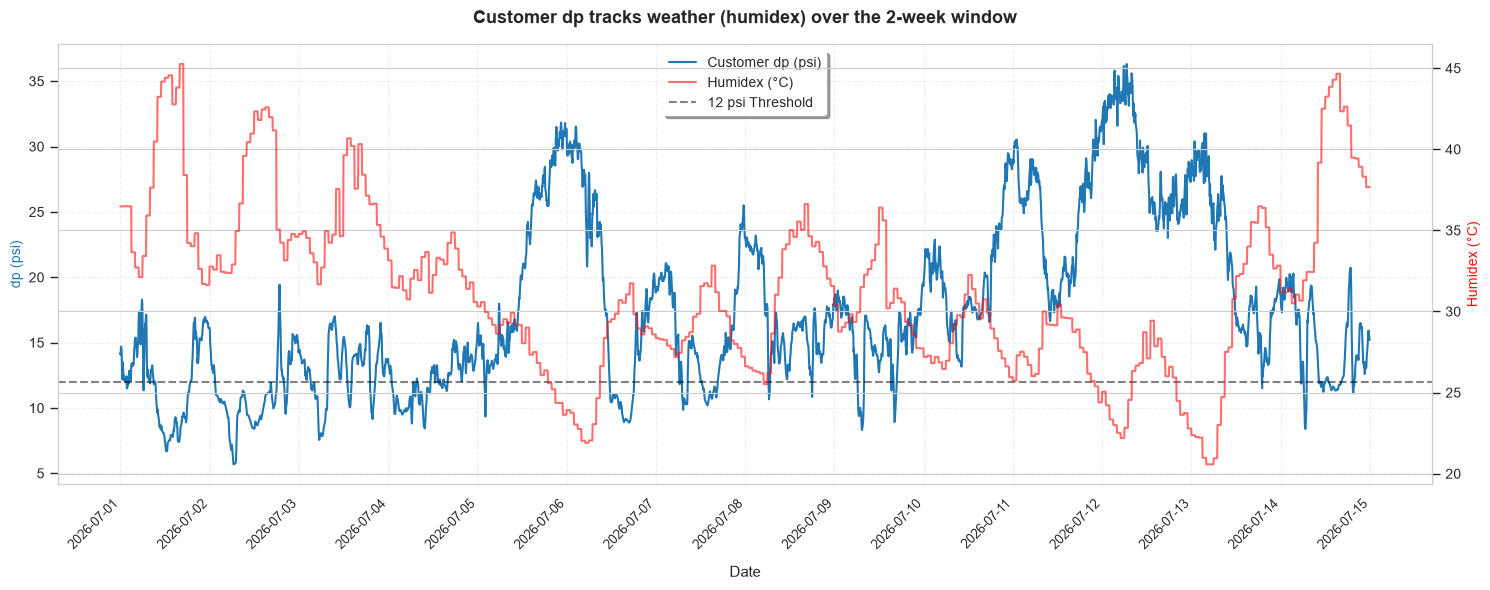

In [89]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(15, 6)) # Slight height increase for rotated labels

# 1. Plot on the primary y-axis
line1, = ax1.plot(merged_df['timestamp'], merged_df['customer_dp_psi'], color='#1f77b4', label='Customer dp (psi)')
thresh_line = ax1.axhline(12, color="#050505", linestyle='--', alpha=0.5, label='12 psi Threshold')
ax1.set_ylabel('dp (psi)', color='#1f77b4')

# 2. Plot on the twin y-axis
ax2 = ax1.twinx()
line2, = ax2.plot(merged_df['timestamp'], merged_df['humidex_c'], color="#ff0e0e", alpha=0.6, label='Humidex (°C)')
ax2.set_ylabel('Humidex (°C)', color="#ff0e0e")

# --- 3. Enhanced X-Axis Date Formatting & Slant ---
# Force daily major ticks and format as YYYY-MM-DD
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=1)) 
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# Slant date labels 45 degrees and align by right edge
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=9)

# Add crisp outward-pointing tick marks on both primary and twin axes
ax1.tick_params(axis='both', which='both', direction='out', length=6, width=1)
ax2.tick_params(axis='y', which='both', direction='out', length=6, width=1)

# 4. Combine handles and labels into one consolidated legend
handles = [line1, line2, thresh_line]
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc='upper center', frameon=True, facecolor='white', edgecolor='none', shadow=True)

# Formatting
ax1.set_xlabel('Date', fontsize=11, labelpad=10)
plt.title('Customer dp tracks weather (humidex) over the 2-week window', fontsize=13, fontweight='bold', pad=15)
ax1.grid(True, linestyle='--', alpha=0.3)

fig.tight_layout()
plt.savefig('dp_vs_humidex_timeseries.png', dpi=150)
plt.show()

**Interaction check (does flow's effect on dp depend on weather?)**

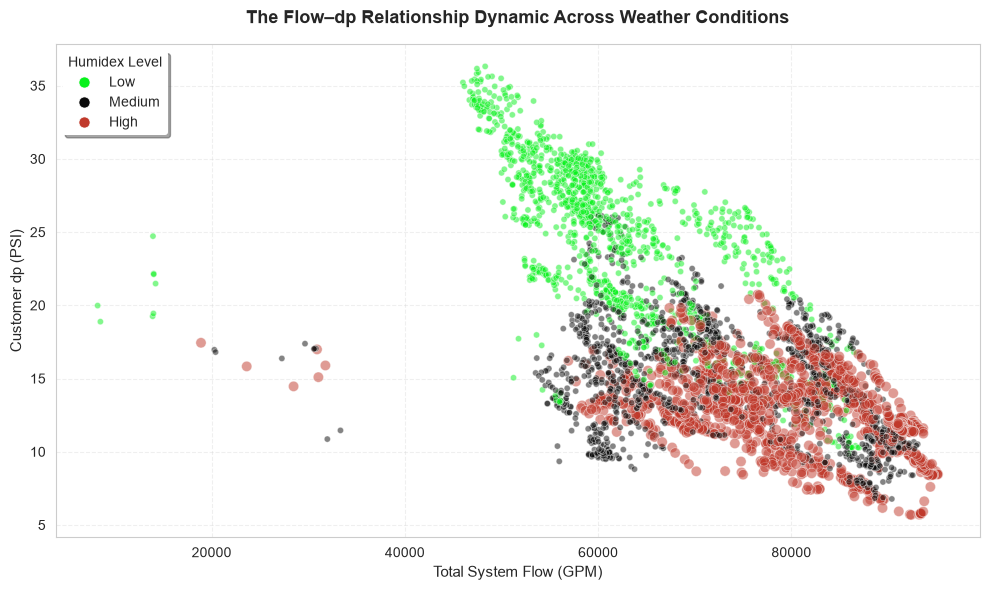

In [54]:
# 1. Engineer the category splits
humidex_cats = pd.qcut(merged_df['humidex_c'], 3, labels=['Low', 'Medium', 'High'])

# 2. Make 'High' points physically larger/thicker on the plot
# High points get a size of 55, while Low and Medium stay at 20
point_sizes = np.where(humidex_cats == 'High', 55, 20)

plt.figure(figsize=(10, 6))

# 3. Plot with your explicit custom color palette
ax = sns.scatterplot(
    data=merged_df, 
    x='total_system_flow_gpm', 
    y='customer_dp_psi',
    hue=humidex_cats, 
    size=point_sizes,         # Applies the variable thickness/sizes
    sizes=(20, 55),           # Maps the min/max boundary explicitly
    alpha=0.5,                
    palette={'Low': "#07F11B", 'Medium': "#0a0a0a", 'High': '#c0392b'}, # Gray, Orange, Thick Red
    edgecolor='white',        
    linewidth=0.5            
)

# 4. Build the legend and filter out the size legend artifact
# (Seaborn adds a size legend when passing arrays; we clean it up by capturing handles)
handles, labels = ax.get_legend_handles_labels()
# Keep only the first 3 handles corresponding to Low, Medium, High
leg = plt.legend(
    handles[:3], 
    labels[:3], 
    title='Humidex Level', 
    loc='upper left', 
    frameon=True, 
    facecolor='white', 
    edgecolor='none', 
    shadow=True
)

# 5. OVERRIDE LEGEND SAFELY: Works for both Line2D and PathCollections
for lh in leg.legend_handles:
    lh.set_alpha(1.0) # Ensure solid colors in the legend box
    if hasattr(lh, 'set_sizes'):
        lh.set_sizes([60])
    elif hasattr(lh, 'set_ms'):
        lh.set_ms(8)  # Safe fallback for Line2D objects to increase marker size

# Final layout touch-ups
plt.title('The Flow–dp Relationship Dynamic Across Weather Conditions', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Total System Flow (GPM)', fontsize=11)
plt.ylabel('Customer dp (PSI)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('flow_humidex_interaction.png', dpi=150)
plt.show()

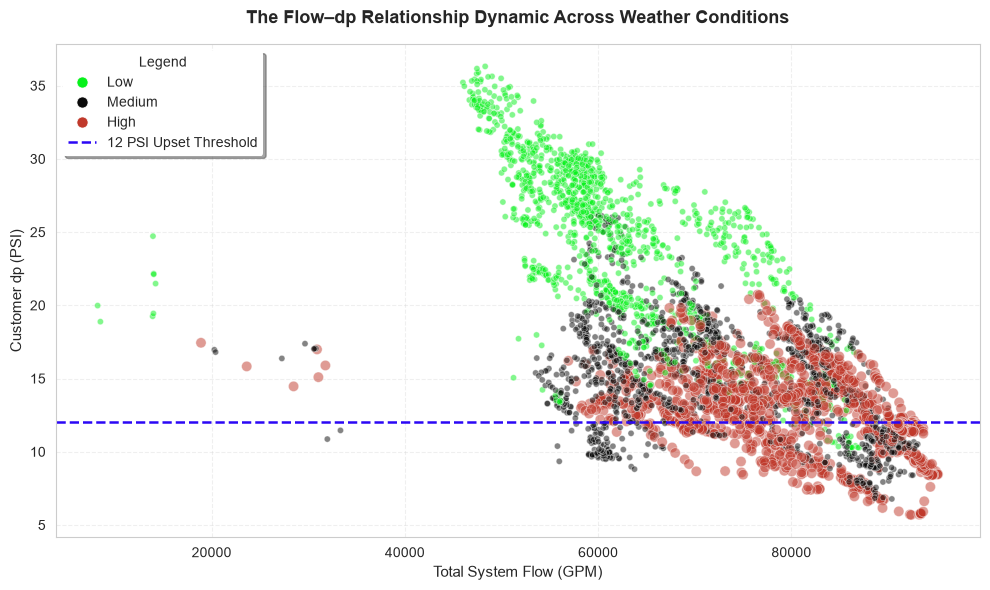

In [88]:
# Define threshold constant if not already set elsewhere
DP_THRESHOLD = 12

# 1. Engineer the category splits
humidex_cats = pd.qcut(merged_df['humidex_c'], 3, labels=['Low', 'Medium', 'High'])

# 2. Make 'High' points physically larger/thicker on the plot
point_sizes = np.where(humidex_cats == 'High', 55, 20)

plt.figure(figsize=(10, 6))

# 3. Plot with your explicit custom color palette
ax = sns.scatterplot(
    data=merged_df, 
    x='total_system_flow_gpm', 
    y='customer_dp_psi',
    hue=humidex_cats, 
    size=point_sizes,         # Applies the variable thickness/sizes
    sizes=(20, 55),           # Maps the min/max boundary explicitly
    alpha=0.5,                
    palette={'Low': "#07F11B", 'Medium': "#0a0a0a", 'High': '#c0392b'}, 
    edgecolor='white',        
    linewidth=0.5,
    zorder=1
)

# --- NEW: Add the 12 PSI Upset Threshold Reference Line ---
threshold_line = plt.axhline(
    y=DP_THRESHOLD, 
    color="#2b07f5", 
    linestyle='--', 
    linewidth=1.8, 
    label='12 PSI Upset Threshold',
    zorder=2
)

# 4. Build the legend and combine Humidex categories with the threshold line
handles, labels = ax.get_legend_handles_labels()

# Filter handles: Keep first 3 (Low, Medium, High) + add the threshold line handle
clean_handles = handles[:3] + [threshold_line]
clean_labels = labels[:3] + ['12 PSI Upset Threshold']

leg = plt.legend(
    clean_handles, 
    clean_labels, 
    title='Legend', 
    loc='upper left', 
    frameon=True, 
    facecolor='white', 
    edgecolor='none', 
    shadow=True
)

# 5. OVERRIDE LEGEND SAFELY: Works for both Line2D (Threshold line) and PathCollections (Scatter points)
for lh in leg.legend_handles:
    lh.set_alpha(1.0) # Ensure solid colors in the legend box
    if hasattr(lh, 'set_sizes'):
        lh.set_sizes([60])
    elif hasattr(lh, 'set_ms'):
        lh.set_ms(8)

# Final layout touch-ups
plt.title('The Flow–dp Relationship Dynamic Across Weather Conditions', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Total System Flow (GPM)', fontsize=11)
plt.ylabel('Customer dp (PSI)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('flow_humidex_interaction.png', dpi=150)
plt.show()

**Exploratory Findings**
- Customer differential pressure (DP) is influenced by several operational and environmental factors—not a single variable.
- Weather (Humidex), total system flow, plant loading, and cooling demand have the strongest relationship with DP.
- As the system experiences hotter weather and higher loads, customer DP consistently decreases.
- Maintaining the target DP (~12 psi) during periods of high demand should be the primary operational focus.

In [55]:
merged_df.columns

Index(['timestamp', 'customer_dp_psi', 'system_output_pressure_psi',
       'system_return_temp_f', 'system_supply_temp_f',
       'total_system_cooling_tons', 'total_system_flow_gpm',
       'plant_1_instantaneous_tons', 'plant_2_instantaneous_tons',
       'plant_1_is_running', 'plant_2_is_running', 'plant_2_data_status',
       'hour_timestamp', 'humidex_c', 'humidex_f', 'date', 'hour',
       'day_of_week', 'is_weekend', 'temperature_delta_f', 'pressure_gap_psi',
       'dp_margin_psi', 'dp_upset', 'dp_status', 'is_peak', 'dp_status_change',
       'dp_status_group'],
      dtype='str')

In [56]:
merged_df.tail()

,timestamp,customer_dp_psi,system_output_pressure_psi,system_return_temp_f,system_supply_temp_f,total_system_cooling_tons,total_system_flow_gpm,plant_1_instantaneous_tons,plant_2_instantaneous_tons,plant_1_is_running,plant_2_is_running,plant_2_data_status,hour_timestamp,humidex_c,humidex_f,date,hour,day_of_week,is_weekend,temperature_delta_f,pressure_gap_psi,dp_margin_psi,dp_upset,dp_status,is_peak,dp_status_change,dp_status_group
4027,2026-07-14 23:35:00,15.919307,103.943118,52.058424,37.692760,51156.022023,72289.377003,0.0,2800.119691,0,1,Valid production,2026-07-14 23:00:00,37.664142,99.795456,2026-07-14,23,Tuesday,0,14.365664,88.023812,3.919307,0,Normal (≥12 PSI),1,False,75
4028,2026-07-14 23:40:00,15.729461,104.099998,51.777817,37.695325,50173.178682,72454.687594,0.0,2069.349288,0,1,Valid production,2026-07-14 23:00:00,37.664142,99.795456,2026-07-14,23,Tuesday,0,14.082492,88.370538,3.729461,0,Normal (≥12 PSI),1,False,75
4029,2026-07-14 23:45:00,15.581089,103.909160,51.804133,37.697889,48746.669408,72892.702722,0.0,1007.453997,0,1,Valid production,2026-07-14 23:00:00,37.664142,99.795456,2026-07-14,23,Tuesday,0,14.106244,88.328071,3.581089,0,Normal (≥12 PSI),1,False,75
4030,2026-07-14 23:50:00,15.314144,103.699997,51.830449,37.700453,49357.898527,73373.704727,0.0,1421.392567,0,1,Valid production,2026-07-14 23:00:00,37.664142,99.795456,2026-07-14,23,Tuesday,0,14.129996,88.385853,3.314144,0,Normal (≥12 PSI),1,False,75
4031,2026-07-14 23:55:00,15.207584,103.507354,52.021292,37.703017,49625.685822,74057.756620,0.0,1456.248744,0,1,Valid production,2026-07-14 23:00:00,37.664142,99.795456,2026-07-14,23,Tuesday,0,14.318275,88.299770,3.207584,0,Normal (≥12 PSI),1,False,75


**Multicollinearity check — VIF, on the clean predictor list**

In [57]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

merged_df['hour_sin'] = np.sin(2 * np.pi * merged_df['hour'] / 24)
merged_df['hour_cos'] = np.cos(2 * np.pi * merged_df['hour'] / 24)

# One temperature representation only (delta), no raw return/supply temps,
# and total_system_cooling_tons dropped as the aggregate redundant with flow + plant tons
predictor_cols = [
    'system_output_pressure_psi', 'total_system_flow_gpm',
    'plant_1_instantaneous_tons', 'plant_2_instantaneous_tons',
    'humidex_c', 'temperature_delta_f', 'hour_sin', 'hour_cos', 'is_weekend'
]

X = merged_df[predictor_cols].dropna()
X_const = sm.add_constant(X)   # required — VIF is meaningless without this

vif_df = pd.DataFrame()
vif_df['variable'] = X_const.columns
vif_df['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif_df = vif_df[vif_df['variable'] != 'const']
vif_df.sort_values('VIF', ascending=False)

,variable,VIF
2,total_system_flow_gpm,4.791904
6,temperature_delta_f,3.114830
4,plant_2_instantaneous_tons,2.878187
8,hour_cos,2.643364
3,plant_1_instantaneous_tons,2.215302
9,is_weekend,2.064078
5,humidex_c,1.985540
7,hour_sin,1.196800
1,system_output_pressure_psi,1.151800


- After removing the redundant aggregate and duplicate temperature representation, and encoding hour cyclically to properly capture its 24-hour rhythm, all nine predictors show low collinearity (VIF < 5) — safe to interpret individual coefficients in the regression.

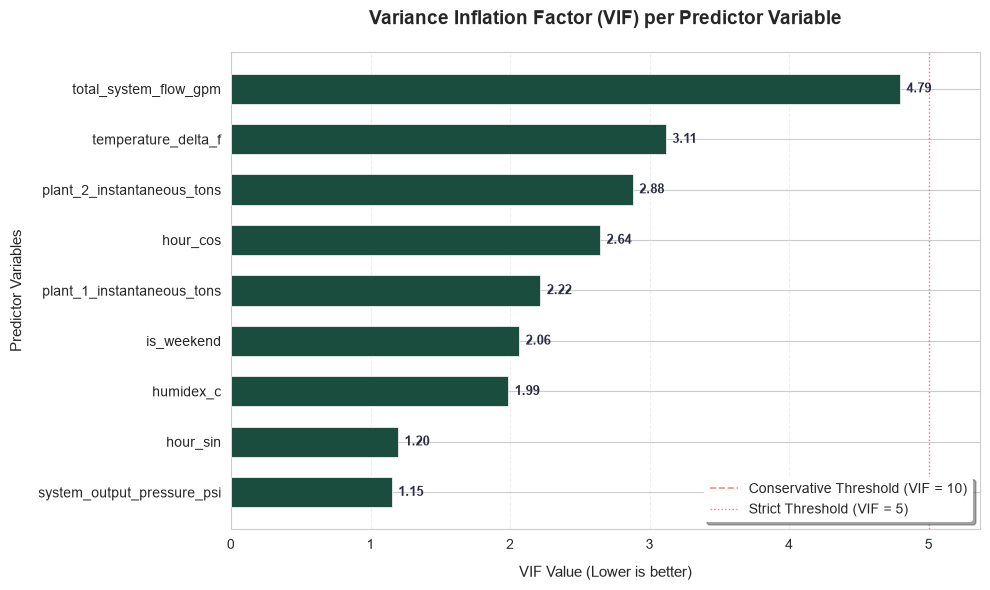

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# (Assuming vif_df is already calculated from your snippet and sorted)
vif_df_sorted = vif_df.sort_values('VIF', ascending=True)

# Initialize a clean, spacious plot layout
fig, ax = plt.subplots(figsize=(10, 6))

# Use a cohesive color scheme (Muted Slate Teal)
ax.barh(
    vif_df_sorted['variable'], 
    vif_df_sorted['VIF'], 
    color='#1b4d3e', 
    edgecolor='white', 
    linewidth=0.5,
    height=0.6,
    zorder=3
)

# Add numeric data labels to the end of each bar for immediate scanning
for index, value in enumerate(vif_df_sorted['VIF']):
    ax.text(
        value + (max(vif_df_sorted['VIF']) * 0.01),  # Dynamic padding to push text out
        index, 
        f'{value:.2f}', 
        va='center', 
        fontsize=9, 
        fontweight='bold',
        color='#2b2d42'
    )

# --- Multicollinearity Threshold Markers ---
# Add a vertical threshold line at VIF = 10 (Strict conservative cutoff)
ax.axvline(10, color='#e07a5f', linestyle='--', linewidth=1.2, alpha=0.8, label='Conservative Threshold (VIF = 10)')
# Optional: Add a second line at VIF = 5 if you want ultra-strict model tuning
ax.axvline(5, color='#d90429', linestyle=':', linewidth=1.0, alpha=0.5, label='Strict Threshold (VIF = 5)')

# Aesthetic Adjustments
ax.set_title('Variance Inflation Factor (VIF) per Predictor Variable', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('VIF Value (Lower is better)', fontsize=11, labelpad=10)
ax.set_ylabel('Predictor Variables', fontsize=11, labelpad=10)

# Expand the x-axis maximum slightly so the data labels do not clip past the frame
ax.set_xlim(0, max(vif_df_sorted['VIF']) * 1.12)

# Set clean structural gridlines
ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Place the legend cleanly
ax.legend(frameon=True, facecolor='white', edgecolor='none', shadow=True, loc='lower right')

plt.tight_layout()
plt.show()

Multicollinearity was low, allowing reliable interpretation of regression coefficients.

In [59]:
merged_df.columns
merged_df.dtypes

timestamp                     datetime64[us]
customer_dp_psi                      float64
system_output_pressure_psi           float64
system_return_temp_f                 float64
system_supply_temp_f                 float64
total_system_cooling_tons            float64
total_system_flow_gpm                float64
plant_1_instantaneous_tons           float64
plant_2_instantaneous_tons           float64
plant_1_is_running                     int64
plant_2_is_running                     int64
plant_2_data_status                      str
hour_timestamp                datetime64[us]
humidex_c                            float64
humidex_f                            float64
date                                  object
hour                                   int32
day_of_week                              str
is_weekend                             int64
temperature_delta_f                  float64
pressure_gap_psi                     float64
dp_margin_psi                        float64
dp_upset  

**Standardizing Predictor Columns**

In [60]:
X = merged_df[predictor_cols].dropna()
y = merged_df.loc[X.index, 'customer_dp_psi']  # keep y aligned to the same rows

X_std = (X - X.mean()) / X.std()

# Verify it worked before moving on
print(X_std.agg(['mean', 'std']).T)

                                    mean  std
system_output_pressure_psi  5.667424e-15  1.0
total_system_flow_gpm       1.184238e-15  1.0
plant_1_instantaneous_tons -7.049035e-17  1.0
plant_2_instantaneous_tons  5.639228e-17  1.0
humidex_c                   3.524518e-16  1.0
temperature_delta_f        -3.101575e-16  1.0
hour_sin                   -2.819614e-17  1.0
hour_cos                    2.467162e-17  1.0
is_weekend                 -1.409807e-16  1.0


**Before fitting (checks on the data itself)**

- Linearity : done (Pearson ≈ Spearman comparison, Image 1)
- No severe multicollinearity : done (VIF, all under 5)
- Standardization : done (just confirmed)

**Multiple Linear Regression**

In [61]:
import statsmodels.api as sm

X_const = sm.add_constant(X_std)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        customer_dp_psi   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     1637.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:47:29   Log-Likelihood:                -10202.
No. Observations:                4032   AIC:                         2.042e+04
Df Residuals:                    4022   BIC:                         2.049e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

**Regression Result Findings**

- This means: About 79% of the changes in customer DP can be explained by the variables in this model. Suppose customer DP goes up and down every day; the model explains almost 8 out of every 10 pressure changes. Only about 21% is caused by things not included in your model (sensor noise, control logic, unknown operational factors, measurement error, etc.). It means none of the variables are just "taking up space."
- F-Statistic answers the question on 'Is the entire regression useful?' - The answer is yes, it is extremely useful because the probability that all variables together have no relationship with DP is essentially zero. The overall model is statistically significant.
- coef tell which drivers have the strongest influence after accounting for every other variable. Eg - Humidex at -3.50. Meaning: Holding everything else constant, higher humidex is associated with lower customer DP. Hotter weather places greater demand on the district energy system, leading to lower customer DP.
-  P-Values (P>|t|) < 0.0001. This means every variable contributes information. Nothing should automatically be removed. It is the strongest predictor in your model.
- Condition Number (Cond. No.) - 5.37  is excellent. Large values (100–1000+) indicate multicollinearity. The value is tiny. That means the predictors are reasonably independent after your feature engineering.

- The regression coefficients tell the direction and relative strength of each variable within the model. They do not prove causation. For example, the positive coefficient for Plant 1 and negative coefficient for Plant 2 suggest different operating behaviors after accounting for the other variables, but they don't necessarily mean changing Plant 1 output alone will increase DP.

**Using HAC Regression to Correct for the severe autocorrelation the Durbin-Watson test of 0.113**

Operational measurements collected every five minutes are highly autocorrelated. HAC robust standard errors were therefore used for statistical inference.

                            OLS Regression Results                            
Dep. Variable:        customer_dp_psi   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     128.0
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          1.84e-212
Time:                        19:47:29   Log-Likelihood:                -10202.
No. Observations:                4032   AIC:                         2.042e+04
Df Residuals:                    4022   BIC:                         2.049e+04
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

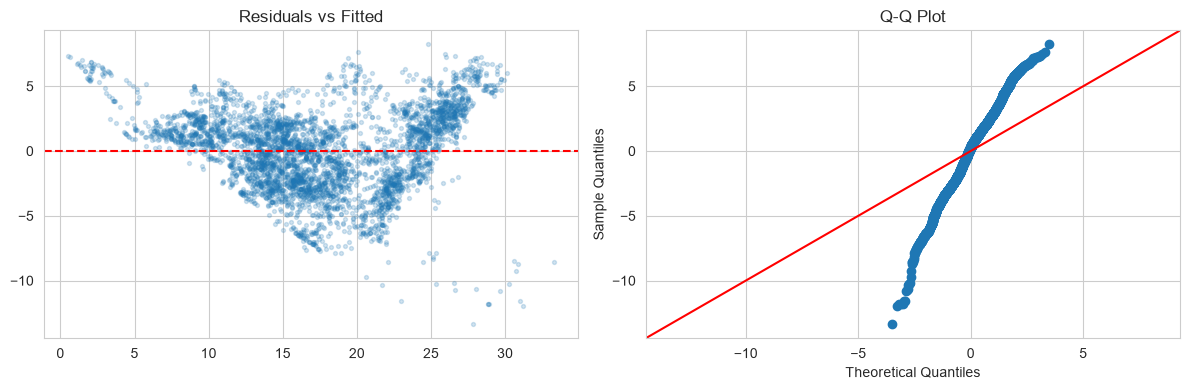

In [62]:
model_robust = sm.OLS(y, X_const).fit(cov_type='HAC', cov_kwds={'maxlags': 12})
print(model_robust.summary())

# Residual diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].scatter(model.fittedvalues, model.resid, alpha=0.2, s=8)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted')

sm.qqplot(model.resid, line='45', ax=axes[1])
axes[1].set_title('Q-Q Plot')
plt.tight_layout()
plt.show()

- corrected for the severe autocorrelation the Durbin-Watson test flagged, temperature_delta_f and is_weekend turned out to be false positives — the previous model was overstating their significance because it was treating autocorrelated rows as independent evidence. The five core operational and weather variables remained statistically robust even under the stricter correction. That gives much higher confidence reporting those five as real drivers, rather than all nine as equally important.
- Weekend itself was not an independent driver once operational conditions were considered

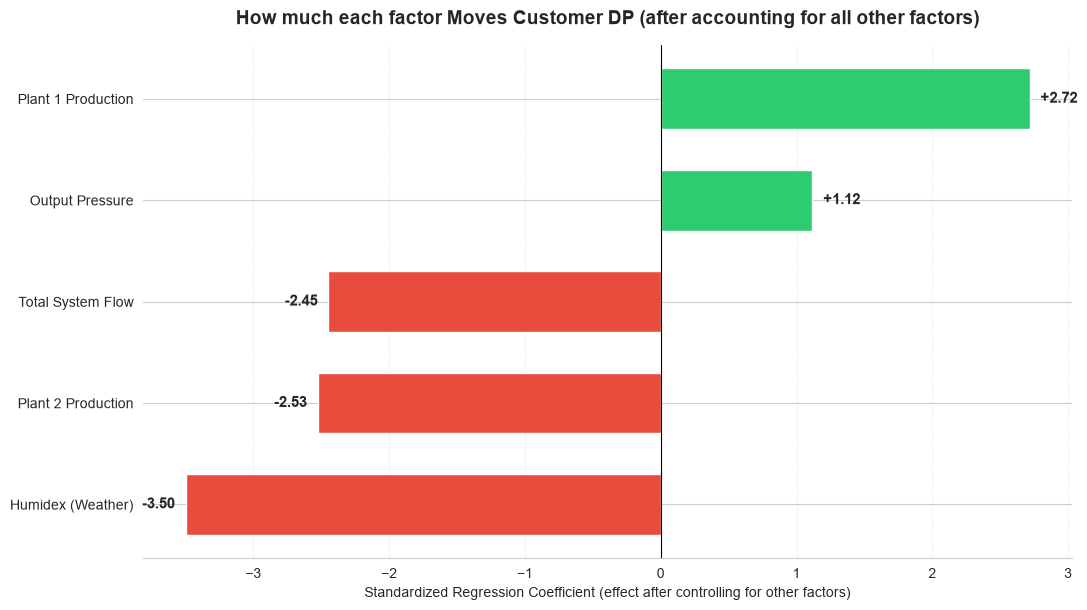

In [95]:
# Standardized regression coefficient chart (replaces cell 97's correlation chart on Slide 7)
# Uses model_robust — the HAC-corrected regression already fit in the cell above

coefs = model_robust.params.drop('const')

# Keep only the headline drivers — drop hour_sin/hour_cos (covered on its own slide already)
# and temperature_delta_f / is_weekend (not significant after HAC correction)
headline_vars = {
    'plant_1_instantaneous_tons': 'Plant 1 Production',
    'system_output_pressure_psi': 'Output Pressure',
    'total_system_flow_gpm': 'Total System Flow',
    'plant_2_instantaneous_tons': 'Plant 2 Production',
    'humidex_c': 'Humidex (Weather)',
}

plot_data = coefs[headline_vars.keys()].rename(index=headline_vars)
plot_data = plot_data.sort_values()  # ascending, so barh reads negative-to-positive bottom-to-top

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in plot_data.values]

plt.figure(figsize=(11, 6.2))
plt.barh(plot_data.index, plot_data.values, color=colors, height=0.6)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Standardized Regression Coefficient (effect after controlling for other factors)')
plt.title('How much each factor Moves Customer DP (after accounting for all other factors)',
          fontsize=14, fontweight='bold', pad=15)

for i, v in enumerate(plot_data.values):
    plt.text(v + (0.08 if v >= 0 else -0.08), i, f'{v:+.2f}',
              va='center', ha='left' if v >= 0 else 'right',
              fontsize=11, fontweight='bold')

plt.gca().spines[['top', 'right', 'left']].set_visible(False)
plt.tick_params(left=False)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('driver_ranking_regression.png', dpi=150, facecolor='white')
plt.show()

**Interaction Effect of Flow and Humidex**

Including interaction and nonlinear terms substantially improved explanatory power i.e R2 0.79 to 0.87

In [63]:
# Interaction: does flow's effect on dp depend on how hot/humid it is?
merged_df['flow_x_humidex'] = merged_df['total_system_flow_gpm'] * merged_df['humidex_c']

# Quadratic: captures the plateau you saw in the binned humidex chart
merged_df['humidex_c_sq'] = merged_df['humidex_c'] ** 2

extended_cols = predictor_cols + ['flow_x_humidex', 'humidex_c_sq']

X2 = merged_df[extended_cols].dropna()
y2 = merged_df.loc[X2.index, 'customer_dp_psi']
X2_std = (X2 - X2.mean()) / X2.std()
X2_std = sm.add_constant(X2_std)

model2 = sm.OLS(y2, X2_std).fit(cov_type='HAC', cov_kwds={'maxlags': 12})
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:        customer_dp_psi   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     323.8
Date:                Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:47:30   Log-Likelihood:                -9275.4
No. Observations:                4032   AIC:                         1.857e+04
Df Residuals:                    4020   BIC:                         1.865e+04
Df Model:                          11                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [64]:
from sklearn.ensemble import RandomForestRegressor
import shap

# Use the same predictor set as your best regression (model2/model3), same X, y
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
rf.fit(X, y)

print("Random Forest R²:", rf.score(X, y))

# Feature importance -- compare ranking against your regression coefficients
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance)

Random Forest R²: 0.9839424183410577
humidex_c                     0.734534
total_system_flow_gpm         0.140334
system_output_pressure_psi    0.026797
plant_2_instantaneous_tons    0.026237
hour_sin                      0.020942
plant_1_instantaneous_tons    0.019394
is_weekend                    0.013680
hour_cos                      0.012135
temperature_delta_f           0.005947
dtype: float64


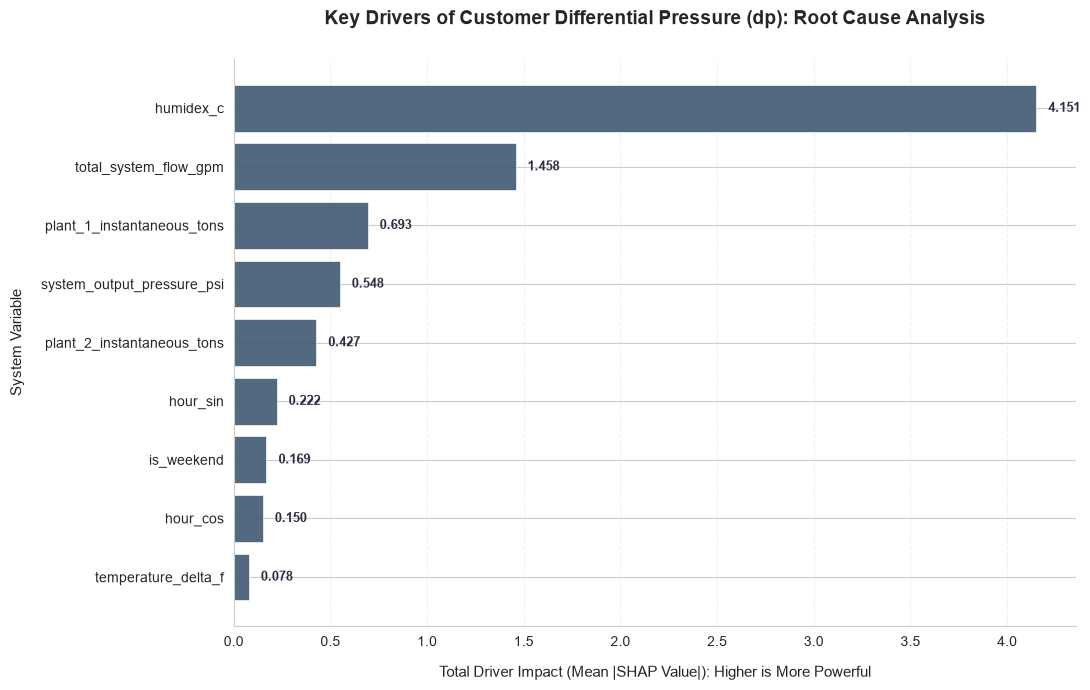

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

# 1. Assuming shap_values and X are already calculated as in your snippet
# shap.TreeExplainer(rf).shap_values(X)

# 2. Extract feature names and calculate absolute mean impact
feature_names = X.columns.tolist()
# Calculate average absolute magnitude per feature (collapsing the swarm)
abs_mean_shap = np.abs(shap_values).mean(axis=0)

# 3. Build a tidy DataFrame and sort top to bottom
shap_df = pd.DataFrame({'Feature': feature_names, 'Impact': abs_mean_shap})
shap_df = shap_df.sort_values('Impact', ascending=True) # Ascending for clean barh chart

# --- Plotting Exec-Friendly Chart ---
# Use a muted, professional operating color (Steel/Slate Blue)
plt.figure(figsize=(11, 7))
ax = plt.gca()

bars = ax.barh(
    shap_df['Feature'], 
    shap_df['Impact'], 
    color="#405971", 
    edgecolor="white", 
    linewidth=0.5,
    alpha=0.9
)

# 4. Add dynamic data labels to the end of each bar for immediate scanning
max_impact = shap_df['Impact'].max()
for i, v in enumerate(shap_df['Impact']):
    ax.text(
        v + (max_impact * 0.015), # Dynamic padding
        i, 
        f'{v:.3f}', 
        va='center', 
        fontsize=9, 
        fontweight='bold', 
        color="#2b2d42"
    )

# Aesthetic adjustments for readability
ax.set_title(
    'Key Drivers of Customer Differential Pressure (dp): Root Cause Analysis', 
    fontsize=14, 
    fontweight='bold', 
    pad=25
)
ax.set_xlabel(
    'Total Driver Impact (Mean |SHAP Value|): Higher is More Powerful', 
    fontsize=11, 
    labelpad=12
)
ax.set_ylabel('System Variable', fontsize=11, labelpad=12)

# Clean grid and borders
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Adjust margins dynamically so labels don't get cut off
plt.tight_layout()

# Save for presentation
plt.savefig('executive_shap_summary.png', dpi=200)
plt.show()

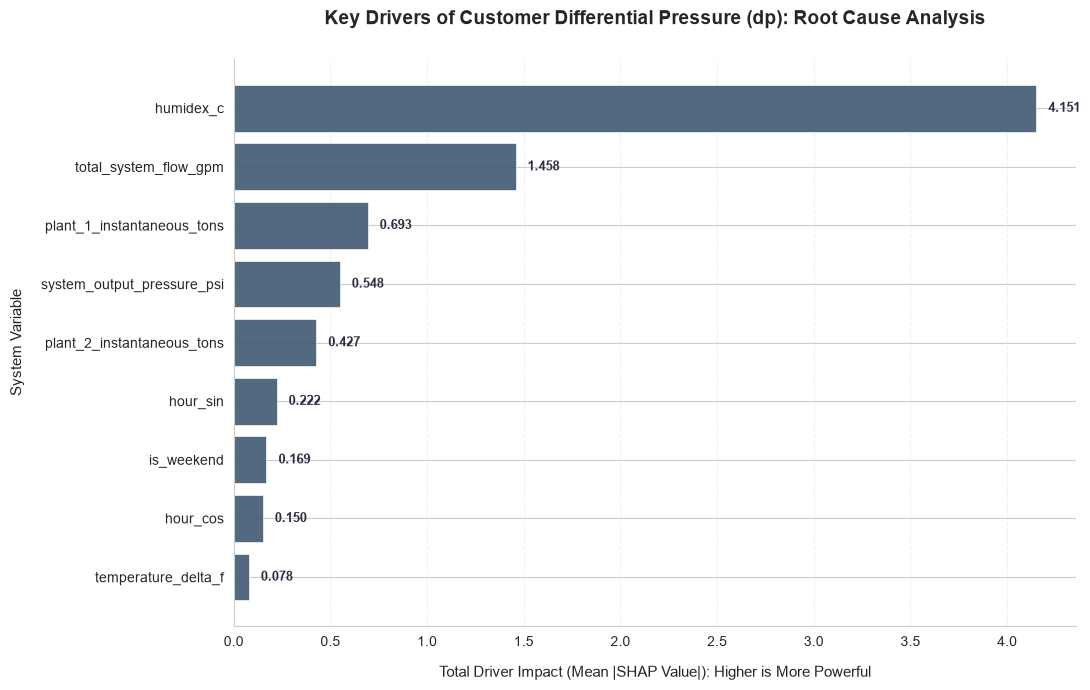

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

# 1. Calculate SHAP values explicitly using your trained Random Forest model (rf)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# 2. Extract feature names and calculate absolute mean impact
feature_names = X.columns.tolist()

# Handle shape differences if shap_values is returned as a list (multi-output) or 2D array
if isinstance(shap_values, list):
    # For regression, tree models usually output a single array, but if list, take primary index
    vals = np.abs(shap_values[0]).mean(axis=0)
else:
    vals = np.abs(shap_values).mean(axis=0)

# 3. Build a tidy DataFrame and sort top to bottom
shap_df = pd.DataFrame({'Feature': feature_names, 'Impact': vals})
shap_df = shap_df.sort_values('Impact', ascending=True) # Ascending for clean barh chart

# --- Plotting Exec-Friendly Chart ---
plt.figure(figsize=(11, 7))
ax = plt.gca()

bars = ax.barh(
    shap_df['Feature'], 
    shap_df['Impact'], 
    color="#405971", 
    edgecolor="white", 
    linewidth=0.5,
    alpha=0.9
)

# 4. Add dynamic data labels to the end of each bar for immediate scanning
max_impact = shap_df['Impact'].max()
for i, v in enumerate(shap_df['Impact']):
    ax.text(
        v + (max_impact * 0.015), # Dynamic padding
        i, 
        f'{v:.3f}', 
        va='center', 
        fontsize=9, 
        fontweight='bold', 
        color="#2b2d42"
    )

# Aesthetic adjustments for readability
ax.set_title(
    'Key Drivers of Customer Differential Pressure (dp): Root Cause Analysis', 
    fontsize=14, 
    fontweight='bold', 
    pad=25
)
ax.set_xlabel(
    'Total Driver Impact (Mean |SHAP Value|): Higher is More Powerful', 
    fontsize=11, 
    labelpad=12
)
ax.set_ylabel('System Variable', fontsize=11, labelpad=12)

# Clean grid and borders
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Adjust margins dynamically so labels don't get cut off
plt.tight_layout()

# Save for presentation
plt.savefig('executive_shap_summary.png', dpi=200)
plt.show()

In [71]:
# ========================================
# Hourly System Demand Profile
# ========================================

hourly_demand_profile = (
    merged_df
    .groupby("hour")
    .agg(
        average_cooling_tons=(
            "total_system_cooling_tons",
            "mean"
        ),
        median_cooling_tons=(
            "total_system_cooling_tons",
            "median"
        ),
        average_flow_gpm=(
            "total_system_flow_gpm",
            "mean"
        ),
        average_humidex_c=(
            "humidex_c",
            "mean"
        ),
        average_dp_psi=(
            "customer_dp_psi",
            "mean"
        ),
        minimum_dp_psi=(
            "customer_dp_psi",
            "min"
        ),
        upset_rate=(
            "dp_upset",
            "mean"
        )
    )
    .reset_index()
)

hourly_demand_profile["upset_rate_pct"] = (
    hourly_demand_profile["upset_rate"] * 100
)

hourly_demand_profile.round(2)

,hour,average_cooling_tons,median_cooling_tons,average_flow_gpm,average_humidex_c,average_dp_psi,minimum_dp_psi,upset_rate,upset_rate_pct
0,0,38516.21,39161.50,61713.60,29.17,20.73,12.19,0.00,0.00
1,1,37215.05,37147.59,59652.29,28.97,20.14,9.54,0.14,13.69
2,2,37347.52,37352.77,59658.49,28.85,19.88,9.34,0.19,19.05
3,3,38151.83,37540.89,60522.40,28.33,19.77,9.49,0.20,19.64
4,4,39494.01,38479.15,62063.92,28.00,19.41,9.26,0.21,21.43
5,5,44516.10,44437.77,67835.53,27.53,17.97,6.78,0.22,22.02
6,6,51332.64,52990.58,72943.22,28.19,16.38,5.68,0.36,36.31
7,7,56186.79,58086.29,74692.78,29.65,16.94,5.79,0.33,32.74
8,8,58930.49,62629.64,74482.83,30.63,17.83,9.70,0.19,19.05
9,9,61677.20,65271.07,77352.36,31.82,16.56,8.43,0.21,20.83


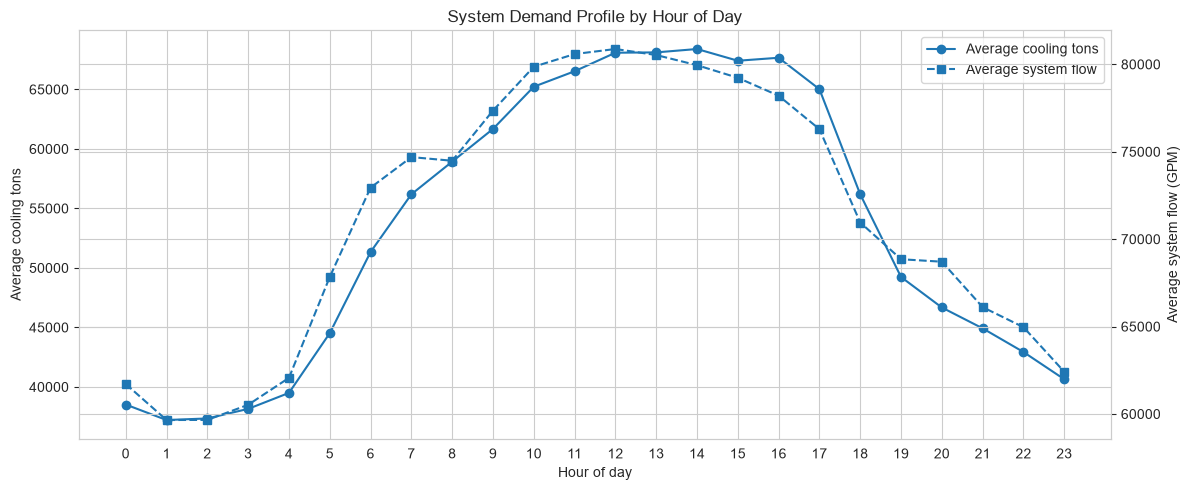

In [72]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    hourly_demand_profile["hour"],
    hourly_demand_profile["average_cooling_tons"],
    marker="o",
    label="Average cooling tons"
)

ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Average cooling tons")
ax1.set_xticks(range(24))

ax2 = ax1.twinx()

ax2.plot(
    hourly_demand_profile["hour"],
    hourly_demand_profile["average_flow_gpm"],
    marker="s",
    linestyle="--",
    label="Average system flow"
)

ax2.set_ylabel("Average system flow (GPM)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

plt.title("System Demand Profile by Hour of Day")
plt.tight_layout()
plt.show()

This chart shows whether high demand is concentrated during specific hours.

In [73]:
# ========================================
# Define Data-Driven Peak Conditions
# ========================================

PEAK_PERCENTILE = 0.75

peak_cooling_threshold = (
    merged_df["total_system_cooling_tons"]
    .quantile(PEAK_PERCENTILE)
)

merged_df["peak_condition"] = np.where(
    merged_df["total_system_cooling_tons"]
    >= peak_cooling_threshold,
    "Peak",
    "Non-Peak"
)

print(
    f"Peak cooling threshold: "
    f"{peak_cooling_threshold:,.2f} tons"
)

print("\nDistribution of observations:")
print(
    merged_df["peak_condition"]
    .value_counts()
)

print("\nPercentage of observations:")
print(
    merged_df["peak_condition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Peak cooling threshold: 67,351.04 tons

Distribution of observations:
peak_condition
Non-Peak    3024
Peak        1008
Name: count, dtype: int64

Percentage of observations:
peak_condition
Non-Peak    75.0
Peak        25.0
Name: proportion, dtype: float64


In [76]:
# ========================================
# Define Data-Driven Peak Conditions
# ========================================

PEAK_PERCENTILE = 0.75

peak_cooling_threshold = (
    merged_df["total_system_cooling_tons"]
    .quantile(PEAK_PERCENTILE)
)

merged_df["peak_condition"] = np.where(
    merged_df["total_system_cooling_tons"]
    >= peak_cooling_threshold,
    "Peak",
    "Non-Peak"
)

print(
    f"Peak cooling threshold: "
    f"{peak_cooling_threshold:,.2f} tons"
)

print("\nDistribution of observations:")
print(
    merged_df["peak_condition"]
    .value_counts()
)

print("\nPercentage of observations:")
print(
    merged_df["peak_condition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Peak cooling threshold: 67,351.04 tons

Distribution of observations:
peak_condition
Non-Peak    3024
Peak        1008
Name: count, dtype: int64

Percentage of observations:
peak_condition
Non-Peak    75.0
Peak        25.0
Name: proportion, dtype: float64


For this analysis, peak conditions were defined as observations in the highest quartile of total cooling production. This data-driven definition should be validated with Operations before production use.

In [77]:
# ========================================
# Validate Peak Classification
# ========================================

peak_validation = (
    merged_df
    .groupby("peak_condition")
    .agg(
        observations=("timestamp", "size"),
        average_cooling_tons=(
            "total_system_cooling_tons",
            "mean"
        ),
        average_flow_gpm=(
            "total_system_flow_gpm",
            "mean"
        ),
        average_humidex_c=(
            "humidex_c",
            "mean"
        ),
        average_dp_psi=(
            "customer_dp_psi",
            "mean"
        ),
        minimum_dp_psi=(
            "customer_dp_psi",
            "min"
        ),
        upset_rate=(
            "dp_upset",
            "mean"
        )
    )
    .reset_index()
)

peak_validation["upset_rate_pct"] = (
    peak_validation["upset_rate"] * 100
)

peak_validation.round(2)

,peak_condition,observations,average_cooling_tons,average_flow_gpm,average_humidex_c,average_dp_psi,minimum_dp_psi,upset_rate,upset_rate_pct
0,Non-Peak,3024,45250.27,66329.26,29.85,18.82,5.93,0.15,15.38
1,Peak,1008,77643.72,85751.60,35.20,13.57,5.68,0.38,37.90


In [78]:
# ========================================
# Peak Assessment: 5-Minute Resolution
# ========================================

peak_5min = (
    merged_df[
        merged_df["peak_condition"] == "Peak"
    ]
    .copy()
)

peak_5min_summary = pd.Series({
    "Peak 5-minute observations":
        len(peak_5min),

    "Average peak DP (PSI)":
        peak_5min["customer_dp_psi"].mean(),

    "Minimum peak DP (PSI)":
        peak_5min["customer_dp_psi"].min(),

    "Peak observations below 12 PSI":
        peak_5min["dp_upset"].sum(),

    "Peak upset rate (%)":
        peak_5min["dp_upset"].mean() * 100
})

peak_5min_summary.round(2)

Peak 5-minute observations        1008.00
Average peak DP (PSI)               13.57
Minimum peak DP (PSI)                5.68
Peak observations below 12 PSI     382.00
Peak upset rate (%)                 37.90
dtype: float64

In [79]:
# ========================================
# Non-Peak Assessment: Hourly Resolution
# ========================================

nonpeak_data = (
    merged_df[
        merged_df["peak_condition"] == "Non-Peak"
    ]
    .copy()
)

nonpeak_data["hour_timestamp"] = (
    nonpeak_data["timestamp"].dt.floor("h")
)

nonpeak_hourly = (
    nonpeak_data
    .groupby("hour_timestamp")
    .agg(
        average_dp_psi=(
            "customer_dp_psi",
            "mean"
        ),
        minimum_dp_psi=(
            "customer_dp_psi",
            "min"
        ),
        average_flow_gpm=(
            "total_system_flow_gpm",
            "mean"
        ),
        average_cooling_tons=(
            "total_system_cooling_tons",
            "mean"
        ),
        average_humidex_c=(
            "humidex_c",
            "mean"
        ),
        five_minute_readings=(
            "timestamp",
            "size"
        )
    )
    .reset_index()
)

# Conservative hourly threshold assessment:
# Flag the hour if any 5-minute reading fell below 12 PSI.
nonpeak_hourly["hourly_upset"] = (
    nonpeak_hourly["minimum_dp_psi"] < DP_THRESHOLD
).astype(int)

nonpeak_hourly["hourly_status"] = np.where(
    nonpeak_hourly["hourly_upset"] == 1,
    "Upset hour",
    "Normal hour"
)

nonpeak_hourly.head()

,hour_timestamp,average_dp_psi,minimum_dp_psi,average_flow_gpm,average_cooling_tons,average_humidex_c,five_minute_readings,hourly_upset,hourly_status
0,2026-07-01 00:00:00,13.532171,12.187216,66705.401266,41993.411824,36.475639,12,0,Normal hour
1,2026-07-01 01:00:00,12.014446,11.501647,67113.277639,42032.893336,36.489639,12,1,Upset hour
2,2026-07-01 02:00:00,12.261184,11.699113,63311.997499,40716.306241,36.480073,12,1,Upset hour
3,2026-07-01 03:00:00,13.759152,13.178561,61362.375004,39598.456157,33.651007,12,0,Normal hour
4,2026-07-01 04:00:00,14.962792,13.894183,61806.340114,39174.328686,32.711485,12,0,Normal hour


In [80]:
nonpeak_hourly_summary = pd.Series({
    "Non-peak hours assessed":
        len(nonpeak_hourly),

    "Average hourly DP (PSI)":
        nonpeak_hourly["average_dp_psi"].mean(),

    "Minimum hourly DP (PSI)":
        nonpeak_hourly["minimum_dp_psi"].min(),

    "Non-peak hours containing an upset":
        nonpeak_hourly["hourly_upset"].sum(),

    "Non-peak hourly upset rate (%)":
        nonpeak_hourly["hourly_upset"].mean() * 100
})

nonpeak_hourly_summary.round(2)

Non-peak hours assessed               263.00
Average hourly DP (PSI)                18.66
Minimum hourly DP (PSI)                 5.93
Non-peak hours containing an upset     57.00
Non-peak hourly upset rate (%)         21.67
dtype: float64

In [81]:
# ========================================
# Peak vs Non-Peak Monitoring Summary
# ========================================

monitoring_summary = pd.DataFrame({
    "Operating Period": [
        "Peak",
        "Non-Peak"
    ],
    "Assessment Resolution": [
        "5 minutes",
        "Hourly"
    ],
    "Number Assessed": [
        len(peak_5min),
        len(nonpeak_hourly)
    ],
    "Average DP (PSI)": [
        peak_5min["customer_dp_psi"].mean(),
        nonpeak_hourly["average_dp_psi"].mean()
    ],
    "Minimum DP (PSI)": [
        peak_5min["customer_dp_psi"].min(),
        nonpeak_hourly["minimum_dp_psi"].min()
    ],
    "Number Below Threshold": [
        peak_5min["dp_upset"].sum(),
        nonpeak_hourly["hourly_upset"].sum()
    ],
    "Threshold Breach Rate (%)": [
        peak_5min["dp_upset"].mean() * 100,
        nonpeak_hourly["hourly_upset"].mean() * 100
    ]
})

monitoring_summary[
    [
        "Average DP (PSI)",
        "Minimum DP (PSI)",
        "Threshold Breach Rate (%)"
    ]
] = monitoring_summary[
    [
        "Average DP (PSI)",
        "Minimum DP (PSI)",
        "Threshold Breach Rate (%)"
    ]
].round(2)

monitoring_summary

,Operating Period,Assessment Resolution,Number Assessed,Average DP (PSI),Minimum DP (PSI),Number Below Threshold,Threshold Breach Rate (%)
0,Peak,5 minutes,1008,13.57,5.68,382,37.90
1,Non-Peak,Hourly,263,18.66,5.93,57,21.67


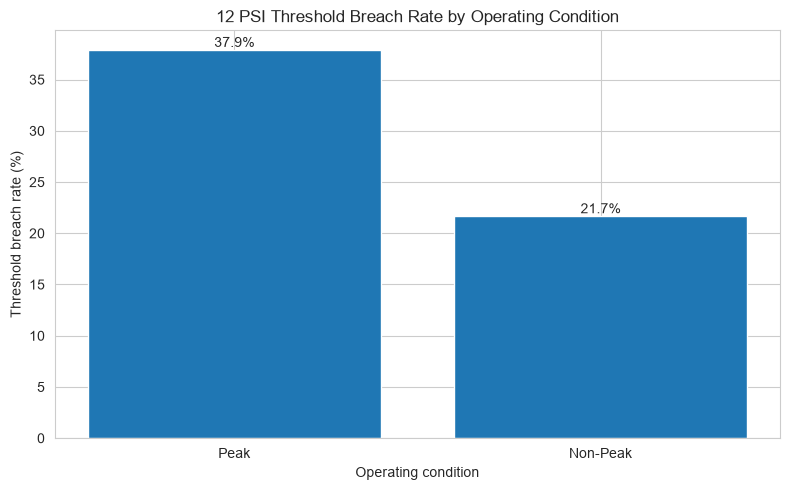

In [82]:
plt.figure(figsize=(8, 5))

plt.bar(
    monitoring_summary["Operating Period"],
    monitoring_summary["Threshold Breach Rate (%)"]
)

plt.title(
    "12 PSI Threshold Breach Rate by Operating Condition"
)

plt.xlabel("Operating condition")
plt.ylabel("Threshold breach rate (%)")

for index, value in enumerate(
    monitoring_summary["Threshold Breach Rate (%)"]
):
    plt.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

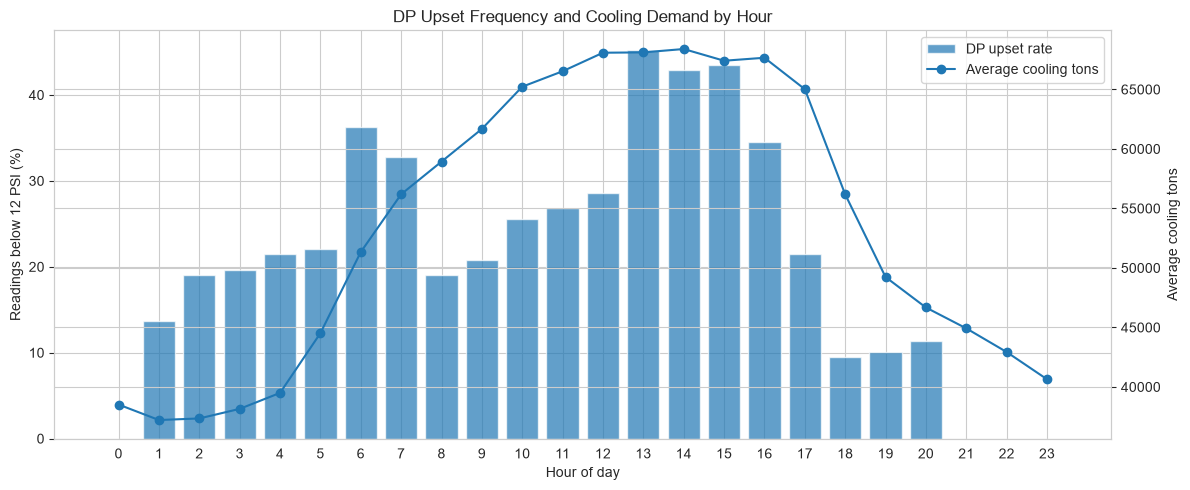

In [83]:
hourly_upset_profile = (
    merged_df
    .groupby("hour")
    .agg(
        upset_rate=("dp_upset", "mean"),
        average_cooling_tons=(
            "total_system_cooling_tons",
            "mean"
        )
    )
    .reset_index()
)

hourly_upset_profile["upset_rate_pct"] = (
    hourly_upset_profile["upset_rate"] * 100
)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(
    hourly_upset_profile["hour"],
    hourly_upset_profile["upset_rate_pct"],
    alpha=0.7,
    label="DP upset rate"
)

ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Readings below 12 PSI (%)")
ax1.set_xticks(range(24))

ax2 = ax1.twinx()

ax2.plot(
    hourly_upset_profile["hour"],
    hourly_upset_profile["average_cooling_tons"],
    marker="o",
    label="Average cooling tons"
)

ax2.set_ylabel("Average cooling tons")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

plt.title("DP Upset Frequency and Cooling Demand by Hour")
plt.tight_layout()
plt.show()

In [91]:
# Export your merged_df DataFrame directly to a CSV file
merged_df.to_csv('merged_operational_data.csv', index=False)

print("✅ Data successfully exported to merged_operational_data.csv")

✅ Data successfully exported to merged_operational_data.csv
